# Statistical Analysis of Multi-Scale Bayesian Optimization Results

Generates statistical tests, summary tables, and publication figures for the bilevel BO paper.

**Sections:**
0. Setup & Configuration
1. Data Loading
2. Per-Problem Statistical Tests (Wilcoxon, effect sizes, Holm-Bonferroni)
3. Summary Tables (LaTeX-ready, hyperparameter sensitivity, NLP comparison)
4. Reproduced Publication Figures (Figs 2-7)
5. New Statistical Figures (forest plot, boxplots, wall time, significance matrix)
6. Paper Claims Validation
7. Export

In [1]:
import sys
import re
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from pathlib import Path
from collections import defaultdict
from scipy.stats import wilcoxon, friedmanchisquare, rankdata, spearmanr

warnings.filterwarnings('ignore')

# ── Add repo root to path ────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from utils import REPORT_FIGS_DIR
from functions import get_all_problems

# Point at results_parallel instead of results/
RESULTS_DIR = REPO_ROOT / 'results_parallel'

# ── Publication-quality matplotlib settings (from figures.ipynb) ──────────────
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 1.5,
    'ytick.minor.size': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.grid': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'figure.dpi': 150,
})

# Column widths (inches)
COL1 = 3.5
COL2 = 7.0

# Colour palette
C_NLP  = '#474747'
C_BBBO = '#0C5DA5'
C_BIBO = '#FF2C00'
C_DE   = '#029E73'
C_FILL = 0.18

print(f'RESULTS_DIR: {RESULTS_DIR}')
print(f'REPORT_FIGS_DIR: {REPORT_FIGS_DIR}')
print('Setup complete.')

RESULTS_DIR: /Users/jeh/Library/CloudStorage/OneDrive-TheUniversityofTexasatAustin/business/UTexas/projects/Greybox Multi-scale Optimization/results_parallel
REPORT_FIGS_DIR: /Users/jeh/Library/CloudStorage/OneDrive-TheUniversityofTexasatAustin/business/UTexas/projects/Greybox Multi-scale Optimization/Report/figs
Setup complete.


In [2]:
# ── Problem metadata and short names ─────────────────────────────────────────
all_probs = get_all_problems()

short_map = {
    'Small-Feasible-Region': 'SFR-1', 'Small-Feasible-Region-2': 'SFR-2',
    'Rastrigin': 'Rast.', 'Toy-Hydrology': 'Hydro.',
    'Rosen-Suzuki': 'R-S', 'CSTR': 'CSTR',
    'Heat-Exchanger': 'HEN', 'PSA': 'PSA',
    'Batch-Reactor': 'Batch', 'Distillation': 'Distill.',
    'Evaporator': 'Evap.', 'Membrane': 'Memb.',
    'Williams-Otto': 'W-O',
}

PROB_META = {}
for pname, p in all_probs.items():
    PROB_META[pname] = {
        'n_wb': p.n_x_wb, 'n_bb': p.n_x_bb, 'n_y': p.n_y, 'n_g': p.n_g,
        'total': p.n_x_wb + p.n_x_bb,
        'short': short_map.get(pname, pname),
    }

# PROBLEM_ORDER and SHORT_NAMES will be finalized after data loading
# (only problems with results will be included)
print(f'{len(all_probs)} problems defined in functions.py')

13 problems defined in functions.py


---
## 1. Data Loading

Dynamically scan `results_parallel/` for individual iteration files
`{Problem}_ninit{N}_xi{X}_it{rep}.pkl`, merge repetitions per
`(problem, n_init, xi)` combination, and determine the best xi per problem
(lowest mean Bi-BO final regret).

In [3]:
# ── Scan results_parallel/ for individual iteration files and merge ───────────
IT_PATTERN = re.compile(r'^(.+)_ninit(\d+)_xi([\d.]+)_it(\d+)\.pkl$')

# First pass: collect file paths grouped by (problem, n_init, xi)
file_groups = defaultdict(list)   # (problem, n_init, xi) -> [(rep_index, fpath), ...]
all_problems_found = set()
all_ninit_found = set()
all_xi_found = set()

for fpath in sorted(RESULTS_DIR.glob('*_it*.pkl')):
    m = IT_PATTERN.match(fpath.name)
    if not m:
        continue
    prob_name = m.group(1)
    ni = int(m.group(2))
    xi = float(m.group(3))
    rep = int(m.group(4))
    file_groups[(prob_name, ni, xi)].append((rep, fpath))
    all_problems_found.add(prob_name)
    all_ninit_found.add(ni)
    all_xi_found.add(xi)

# Second pass: load and merge individual files into combined dicts
all_data = {}          # (problem, n_init, xi) -> merged dict (same format as old combined files)

def _merge_solver_dicts(accumulated, single):
    """Append all list-valued entries from single into accumulated."""
    for k, v in single.items():
        if isinstance(v, list):
            accumulated.setdefault(k, []).extend(v)
        elif k not in accumulated:
            accumulated[k] = v

for key, rep_files in file_groups.items():
    prob_name, ni, xi = key
    rep_files.sort(key=lambda x: x[0])  # sort by rep index

    merged_settings = None
    merged_solvers = {}   # solver_key -> merged dict
    scalar_fields = {}    # non-solver scalar fields (problem, J_optimal, etc.)

    for rep_idx, fpath in rep_files:
        with open(fpath, 'rb') as f:
            d = pickle.load(f)
        if merged_settings is None:
            merged_settings = d['settings'].copy()

        prob_results = d['results'][prob_name]
        for rk, rv in prob_results.items():
            if isinstance(rv, dict):
                merged_solvers.setdefault(rk, {})
                _merge_solver_dicts(merged_solvers[rk], rv)
            else:
                scalar_fields[rk] = rv

    # Combine scalar fields and solver dicts
    combined_results = {**scalar_fields, **merged_solvers}

    # Update settings to reflect the merged repetition count
    merged_settings['n_repetitions'] = len(rep_files)
    if 'rep_index' in merged_settings:
        del merged_settings['rep_index']

    all_data[key] = {'settings': merged_settings, 'results': {prob_name: combined_results}}

ninit_values = sorted(all_ninit_found)
xi_values = sorted(all_xi_found)

print(f'Loaded {sum(len(v) for v in file_groups.values())} individual iteration files '
      f'-> {len(all_data)} merged (problem, n_init, xi) groups')
print(f'Problems ({len(all_problems_found)}): {sorted(all_problems_found)}')
print(f'n_init values: {ninit_values}')
print(f'xi values: {xi_values}')

# Spot-check: print rep counts per group
rep_counts = set(len(v) for v in file_groups.values())
print(f'Reps per group: {rep_counts}')

Loaded 2730 individual iteration files -> 273 merged (problem, n_init, xi) groups
Problems (13): ['Batch-Reactor', 'CSTR', 'Distillation', 'Evaporator', 'Heat-Exchanger', 'Membrane', 'PSA', 'Rastrigin', 'Rosen-Suzuki', 'Small-Feasible-Region', 'Small-Feasible-Region-2', 'Toy-Hydrology', 'Williams-Otto']
n_init values: [5, 25, 50]
xi values: [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
Reps per group: {10}


In [4]:
# ── Determine best xi per (problem, n_init) ──────────────────────────────────
# Best xi = the one that minimizes mean |final regret| of Bi-BO across reps.

def _mean_bi_regret(d, prob_name):
    """Mean absolute final regret for bilevel BO in a loaded result dict."""
    results = d['results'][prob_name]
    bi_finals = [np.abs(r[-1]) for r in results['bilevel_bo_ei']['regrets']
                 if np.isfinite(r[-1])]
    return np.mean(bi_finals) if bi_finals else np.inf


best_xi = {}   # (problem, n_init) -> best xi value

for prob_name in sorted(all_problems_found):
    for ni in ninit_values:
        best, best_val = None, np.inf
        for xi in xi_values:
            key = (prob_name, ni, xi)
            if key not in all_data:
                continue
            val = _mean_bi_regret(all_data[key], prob_name)
            if val < best_val:
                best_val = val
                best = xi
        if best is not None:
            best_xi[(prob_name, ni)] = best

# Build xibest_data: {n_init -> merged result dict} using per-problem best xi
# Each entry mirrors the old format: {'settings': ..., 'results': {pname: ...}}
xibest_data = {}

for ni in ninit_values:
    merged_results = {}
    settings = None
    for prob_name in sorted(all_problems_found):
        xi_star = best_xi.get((prob_name, ni))
        if xi_star is None:
            continue
        d = all_data[(prob_name, ni, xi_star)]
        if settings is None:
            settings = d['settings'].copy()
        merged_results[prob_name] = d['results'][prob_name]
    xibest_data[ni] = {'settings': settings, 'results': merged_results}

# Representative dataset
ref_ni = ninit_values[0] if ninit_values else 5
data = xibest_data[ref_ni]
problem_names = list(data['results'].keys())
n_init_default = data['settings']['n_initial']
n_iter_default = data['settings']['n_iterations']

# Finalize ordering (only problems with results)
PROBLEM_ORDER = problem_names
SHORT_NAMES = [PROB_META[p]['short'] for p in PROBLEM_ORDER]

print(f'Best xi per problem (n_init={ref_ni}):')
for pname in problem_names:
    print(f'  {pname:<28s}  xi* = {best_xi[(pname, ref_ni)]}')
print(f'\nProblems ({len(problem_names)}): {problem_names}')
print(f'Settings: n_init={n_init_default}, n_iter={n_iter_default}, '
      f'n_reps={data["settings"]["n_repetitions"]}')

Best xi per problem (n_init=5):
  Batch-Reactor                 xi* = 0.001
  CSTR                          xi* = 0.001
  Distillation                  xi* = 0.001
  Evaporator                    xi* = 0.001
  Heat-Exchanger                xi* = 0.001
  Membrane                      xi* = 0.001
  PSA                           xi* = 0.001
  Rastrigin                     xi* = 0.001
  Rosen-Suzuki                  xi* = 0.001
  Small-Feasible-Region         xi* = 0.01
  Small-Feasible-Region-2       xi* = 0.001
  Toy-Hydrology                 xi* = 0.01
  Williams-Otto                 xi* = 0.001

Problems (13): ['Batch-Reactor', 'CSTR', 'Distillation', 'Evaporator', 'Heat-Exchanger', 'Membrane', 'PSA', 'Rastrigin', 'Rosen-Suzuki', 'Small-Feasible-Region', 'Small-Feasible-Region-2', 'Toy-Hydrology', 'Williams-Otto']
Settings: n_init=5, n_iter=200, n_reps=10


In [5]:
# ── Reshape all_data into (n_init, xi) -> merged dict for downstream cells ───
# Downstream cells (scatter, heatmap, sensitivity) expect all_data keyed by
# (n_init, xi) with results for ALL problems merged into one dict.

all_data_merged = {}   # (n_init, xi) -> {'settings': ..., 'results': {pname: ...}}

for ni in ninit_values:
    for xi in xi_values:
        merged_results = {}
        settings = None
        for prob_name in problem_names:
            key = (prob_name, ni, xi)
            if key not in all_data:
                continue
            d = all_data[key]
            if settings is None:
                settings = d['settings'].copy()
            merged_results[prob_name] = d['results'][prob_name]
        if merged_results:
            all_data_merged[(ni, xi)] = {'settings': settings, 'results': merged_results}

print(f'Merged {len(all_data_merged)} (n_init, xi) configurations '
      f'(expected {len(ninit_values) * len(xi_values)})')

# ── Build master DataFrame from xibest data ──────────────────────────────────
rows = []

for ni in ninit_values:
    d = xibest_data[ni]
    settings = d['settings']
    results = d['results']

    for pname in problem_names:
        prob = results[pname]

        # NLP
        for rep_idx in range(len(prob['multistart_slsqp']['final_regrets'])):
            rows.append({
                'n_init': ni, 'xi': 'best', 'problem': pname, 'method': 'NLP',
                'rep': rep_idx,
                'final_regret': prob['multistart_slsqp']['final_regrets'][rep_idx],
                'n_bb_evals': prob['multistart_slsqp']['n_fbb_evals'][rep_idx],
                'wall_time': prob['multistart_slsqp']['wall_times'][rep_idx],
                'best_J': prob['multistart_slsqp']['best_Js'][rep_idx],
            })

        # DE
        for rep_idx in range(len(prob['basin_hopping']['final_regrets'])):
            rows.append({
                'n_init': ni, 'xi': 'best', 'problem': pname, 'method': 'DE',
                'rep': rep_idx,
                'final_regret': prob['basin_hopping']['final_regrets'][rep_idx],
                'n_bb_evals': prob['basin_hopping']['n_fbb_evals'][rep_idx],
                'wall_time': prob['basin_hopping']['wall_times'][rep_idx],
                'best_J': prob['basin_hopping']['best_Js'][rep_idx],
            })

        # BB-BO and Bi-BO
        for method_key, method_label in [('blackbox_bo_ei', 'BB-BO'),
                                          ('bilevel_bo_ei', 'Bi-BO')]:
            solver = prob[method_key]
            for rep_idx in range(len(solver['regrets'])):
                regret_curve = solver['regrets'][rep_idx]
                final_r = regret_curve[-1] if len(regret_curve) > 0 else np.nan
                rows.append({
                    'n_init': ni, 'xi': 'best', 'problem': pname,
                    'method': method_label, 'rep': rep_idx,
                    'final_regret': final_r,
                    'n_bb_evals': solver['n_fbb_evals'][rep_idx],
                    'wall_time': solver['wall_times'][rep_idx],
                    'best_J': solver['best_Js'][rep_idx],
                })

df = pd.DataFrame(rows)
df['abs_final_regret'] = df['final_regret'].abs()

# Replace non-finite values with NaN
df.loc[~np.isfinite(df['final_regret']), 'final_regret'] = np.nan
df.loc[~np.isfinite(df['abs_final_regret']), 'abs_final_regret'] = np.nan

print(f'Master DataFrame: {len(df)} rows')
print(f'Methods: {df["method"].unique()}')
print(f'n_init configs: {sorted(df["n_init"].unique())}')
df.groupby(['method', 'n_init']).size().unstack(fill_value=0)

Merged 21 (n_init, xi) configurations (expected 21)
Master DataFrame: 1560 rows
Methods: ['NLP' 'DE' 'BB-BO' 'Bi-BO']
n_init configs: [np.int64(5), np.int64(25), np.int64(50)]


n_init,5,25,50
method,,,
BB-BO,130,130,130
Bi-BO,130,130,130
DE,130,130,130
NLP,130,130,130


---
## 2. Statistical Tests: BB-BO vs Bi-BO

Per-problem Wilcoxon signed-rank tests with rank-biserial effect sizes and Holm-Bonferroni correction.

In [6]:
# ── Wilcoxon signed-rank tests with effect sizes ─────────────────────────────
# Using n_init=5, xibest as the representative configuration

res = xibest_data[5]['results']
stat_rows = []

for pname in problem_names:
    prob = res[pname]
    bb_finals = np.array([r[-1] for r in prob['blackbox_bo_ei']['regrets']])
    bi_finals = np.array([r[-1] for r in prob['bilevel_bo_ei']['regrets']])

    # Replace non-finite with NaN
    bb_finals = np.where(np.isfinite(bb_finals), bb_finals, np.nan)
    bi_finals = np.where(np.isfinite(bi_finals), bi_finals, np.nan)

    # Drop paired NaN
    valid = np.isfinite(bb_finals) & np.isfinite(bi_finals)
    bb_v = bb_finals[valid]
    bi_v = bi_finals[valid]
    n_valid = len(bb_v)

    # Wilcoxon signed-rank (two-sided)
    if n_valid >= 5 and not np.allclose(bb_v, bi_v):
        stat, p_raw = wilcoxon(bb_v, bi_v, alternative='two-sided')
        # Rank-biserial r = 1 - 2W / (n*(n+1)/2)
        r_rb = 1.0 - (2.0 * stat) / (n_valid * (n_valid + 1) / 2)
    else:
        stat, p_raw, r_rb = np.nan, 1.0, 0.0

    # Cliff's delta
    n_greater = np.sum(np.abs(bb_v[:, None]) > np.abs(bi_v[None, :]))
    n_less = np.sum(np.abs(bb_v[:, None]) < np.abs(bi_v[None, :]))
    cliffs_d = (n_greater - n_less) / (n_valid ** 2) if n_valid > 0 else 0.0

    # Effect size interpretation
    abs_r = abs(r_rb)
    if abs_r >= 0.5:
        interp = 'large'
    elif abs_r >= 0.3:
        interp = 'medium'
    elif abs_r >= 0.1:
        interp = 'small'
    else:
        interp = 'negligible'

    # Regret ratio
    bb_mean = np.nanmean(np.abs(bb_v))
    bi_mean = np.nanmean(np.abs(bi_v))
    ratio = bb_mean / max(bi_mean, 1e-15)

    stat_rows.append({
        'problem': pname,
        'short': PROB_META[pname]['short'],
        'n_wb': PROB_META[pname]['n_wb'],
        'n_bb': PROB_META[pname]['n_bb'],
        'n_g': PROB_META[pname]['n_g'],
        'total_dim': PROB_META[pname]['total'],
        'bb_mean': bb_mean,
        'bb_std': np.nanstd(np.abs(bb_v)),
        'bi_mean': bi_mean,
        'bi_std': np.nanstd(np.abs(bi_v)),
        'regret_ratio': ratio,
        'W_stat': stat,
        'p_raw': p_raw,
        'r_rb': r_rb,
        'cliffs_d': cliffs_d,
        'effect_interp': interp,
        'n_valid': n_valid,
    })

df_stats = pd.DataFrame(stat_rows)

# ── Holm-Bonferroni correction ───────────────────────────────────────────────
m = len(df_stats)
sorted_idx = df_stats['p_raw'].argsort().values
p_adjusted = np.ones(m)

for rank_pos, orig_idx in enumerate(sorted_idx):
    p_adj = df_stats.loc[orig_idx, 'p_raw'] * (m - rank_pos)
    p_adjusted[orig_idx] = min(p_adj, 1.0)

# Enforce monotonicity (adjusted p can't decrease along sorted order)
for i in range(1, m):
    idx = sorted_idx[i]
    prev_idx = sorted_idx[i - 1]
    p_adjusted[idx] = max(p_adjusted[idx], p_adjusted[prev_idx])

df_stats['p_adjusted'] = p_adjusted
df_stats['significant'] = df_stats['p_adjusted'] < 0.05

# Significance stars
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

df_stats['stars'] = df_stats['p_adjusted'].apply(sig_stars)

print(f'{df_stats["significant"].sum()}/{m} problems significant at p_adj < 0.05')

12/13 problems significant at p_adj < 0.05


In [7]:
# ── Display per-problem results table ────────────────────────────────────────
print(f'{"Problem":<24s} {"BB-BO mean":>12s} {"Bi-BO mean":>12s} '
      f'{"Ratio":>10s} {"p_adj":>10s} {"Sig":>5s} {"r_rb":>6s} {"Effect":>10s}')
print('-' * 95)

for _, row in df_stats.iterrows():
    print(f'{row["problem"]:<24s} {row["bb_mean"]:>12.4e} {row["bi_mean"]:>12.4e} '
          f'{row["regret_ratio"]:>10.1f}x {row["p_adjusted"]:>10.4f} '
          f'{row["stars"]:>5s} {row["r_rb"]:>6.3f} {row["effect_interp"]:>10s}')

print(f'\nGeometric mean regret ratio: '
      f'{np.exp(np.mean(np.log(df_stats["regret_ratio"]))):.1f}x')
print(f'Range: {df_stats["regret_ratio"].min():.1f}x – '
      f'{df_stats["regret_ratio"].max():.0f}x')

Problem                    BB-BO mean   Bi-BO mean      Ratio      p_adj   Sig   r_rb     Effect
-----------------------------------------------------------------------------------------------
Batch-Reactor              2.8938e-01   4.4260e-04      653.8x     0.0254     *  1.000      large
CSTR                       3.3589e-01   1.9550e-03      171.8x     0.0254     *  1.000      large
Distillation               5.2127e+03   5.0493e-03  1032360.8x     0.0254     *  1.000      large
Evaporator                 3.7602e-01   1.3030e-03      288.6x     0.0254     *  1.000      large
Heat-Exchanger             7.0563e+01   4.9128e-07 143629503.0x     0.0254     *  1.000      large
Membrane                   1.2062e+00   9.0742e-06   132921.1x     0.0254     *  1.000      large
PSA                        9.0526e-02   8.5377e-05     1060.3x     0.0254     *  1.000      large
Rastrigin                  3.0070e+00   3.1485e-08 95506276.4x     0.0254     *  1.000      large
Rosen-Suzuki          

In [8]:
# ── Friedman test: omnibus comparison of NLP, BB-BO, Bi-BO ──────────────────
# Build matrix: rows=problems, cols=methods, values=mean final regret

res = xibest_data[5]['results']
methods_friedman = ['NLP', 'BB-BO', 'Bi-BO']
regret_matrix = np.zeros((len(problem_names), 3))

for pi, pname in enumerate(problem_names):
    prob = res[pname]
    # NLP
    nlp_regrets = np.array(prob['multistart_slsqp']['final_regrets'])
    regret_matrix[pi, 0] = np.nanmean(np.abs(nlp_regrets))
    # BB-BO
    bb_finals = np.array([r[-1] for r in prob['blackbox_bo_ei']['regrets']])
    regret_matrix[pi, 1] = np.nanmean(np.abs(bb_finals[np.isfinite(bb_finals)]))
    # Bi-BO
    bi_finals = np.array([r[-1] for r in prob['bilevel_bo_ei']['regrets']])
    regret_matrix[pi, 2] = np.nanmean(np.abs(bi_finals[np.isfinite(bi_finals)]))

# Rank within each problem (lower regret = better rank = rank 1)
rank_matrix = np.zeros_like(regret_matrix)
for pi in range(len(problem_names)):
    rank_matrix[pi] = rankdata(regret_matrix[pi])

mean_ranks = rank_matrix.mean(axis=0)

# Friedman test
stat_f, p_f = friedmanchisquare(*[rank_matrix[:, j] for j in range(3)])

print('Friedman Test (NLP vs BB-BO vs Bi-BO)')
print('=' * 50)
for j, mname in enumerate(methods_friedman):
    print(f'  {mname:<8s}: mean rank = {mean_ranks[j]:.2f}')
print(f'\n  Chi-sq = {stat_f:.3f}, p = {p_f:.6f}')

# Nemenyi post-hoc critical difference
k = 3   # number of methods
n = len(problem_names)  # number of problems
q_alpha_3 = 2.343  # q_{0.05, 3} from studentized range table
CD = q_alpha_3 * np.sqrt(k * (k + 1) / (6 * n))
print(f'\n  Nemenyi CD (alpha=0.05) = {CD:.3f}')
print(f'  Pairwise rank differences:')
for i in range(k):
    for j in range(i + 1, k):
        diff = abs(mean_ranks[i] - mean_ranks[j])
        sig = '* SIGNIFICANT' if diff > CD else ''
        print(f'    {methods_friedman[i]} vs {methods_friedman[j]}: '
              f'|{mean_ranks[i]:.2f} - {mean_ranks[j]:.2f}| = {diff:.2f} {sig}')

Friedman Test (NLP vs BB-BO vs Bi-BO)
  NLP     : mean rank = 1.54
  BB-BO   : mean rank = 2.77
  Bi-BO   : mean rank = 1.69

  Chi-sq = 11.692, p = 0.002891

  Nemenyi CD (alpha=0.05) = 0.919
  Pairwise rank differences:
    NLP vs BB-BO: |1.54 - 2.77| = 1.23 * SIGNIFICANT
    NLP vs Bi-BO: |1.54 - 1.69| = 0.15 
    BB-BO vs Bi-BO: |2.77 - 1.69| = 1.08 * SIGNIFICANT


In [9]:
# ── Wall time comparison ─────────────────────────────────────────────────────
res = xibest_data[5]['results']
time_rows = []

for pname in problem_names:
    prob = res[pname]
    bb_times = np.array(prob['blackbox_bo_ei']['wall_times'])
    bi_times = np.array(prob['bilevel_bo_ei']['wall_times'])

    valid = np.isfinite(bb_times) & np.isfinite(bi_times)
    bb_t = bb_times[valid]
    bi_t = bi_times[valid]

    if len(bb_t) >= 5:
        _, p_time = wilcoxon(bb_t, bi_t, alternative='two-sided')
    else:
        p_time = 1.0

    ratio = np.mean(bi_t) / max(np.mean(bb_t), 1e-10)
    time_rows.append({
        'problem': pname,
        'short': PROB_META[pname]['short'],
        'bb_time_mean': np.mean(bb_t),
        'bb_time_std': np.std(bb_t),
        'bi_time_mean': np.mean(bi_t),
        'bi_time_std': np.std(bi_t),
        'time_ratio': ratio,
        'p_time': p_time,
        'comparable': 0.5 <= ratio <= 2.0,
    })

df_time = pd.DataFrame(time_rows)

print(f'{"Problem":<24s} {"BB-BO (s)":>12s} {"Bi-BO (s)":>12s} {"Ratio":>8s} {"Comp.":>6s}')
print('-' * 66)
for _, row in df_time.iterrows():
    mark = 'Y' if row['comparable'] else 'N'
    print(f'{row["problem"]:<24s} {row["bb_time_mean"]:>10.2f}s {row["bi_time_mean"]:>10.2f}s '
          f'{row["time_ratio"]:>7.2f}x {mark:>6s}')

n_comp = df_time['comparable'].sum()
print(f'\nComparable wall time (within 2x): {n_comp}/{len(df_time)} problems')

Problem                     BB-BO (s)    Bi-BO (s)    Ratio  Comp.
------------------------------------------------------------------
Batch-Reactor                329.08s     336.71s    1.02x      Y
CSTR                         318.30s     267.25s    0.84x      Y
Distillation                 261.48s     227.97s    0.87x      Y
Evaporator                   320.34s     247.25s    0.77x      Y
Heat-Exchanger               294.71s     228.99s    0.78x      Y
Membrane                     265.63s     262.35s    0.99x      Y
PSA                          321.01s     265.47s    0.83x      Y
Rastrigin                    242.41s     164.89s    0.68x      Y
Rosen-Suzuki                 285.37s     348.73s    1.22x      Y
Small-Feasible-Region        202.24s     810.77s    4.01x      N
Small-Feasible-Region-2      196.12s     148.88s    0.76x      Y
Toy-Hydrology                228.33s     172.25s    0.75x      Y
Williams-Otto                297.20s    3074.13s   10.34x      N

Comparable wall time

---
## 3. Summary Tables

In [10]:
# ── Main results table (LaTeX-ready) ─────────────────────────────────────────
# Columns: Problem, n_wb, n_bb, n_g, NLP regret, BB-BO regret, Bi-BO regret,
#          Ratio (BB/Bi), p_adj, Sig

res = xibest_data[5]['results']

latex_rows = []
for _, row in df_stats.iterrows():
    pname = row['problem']
    prob = res[pname]
    nlp_regrets = np.abs(prob['multistart_slsqp']['final_regrets'])
    nlp_mean = np.mean(nlp_regrets)

    latex_rows.append({
        'Problem': row['short'],
        '$n^{\\mathrm{WB}}$': row['n_wb'],
        '$n^{\\mathrm{BB}}$': row['n_bb'],
        '$n_g$': row['n_g'],
        'NLP': f'{nlp_mean:.2e}',
        'BB-BO': f'{row["bb_mean"]:.2e}',
        'Bi-BO': f'{row["bi_mean"]:.2e}',
        'Ratio': f'{row["regret_ratio"]:.0f}$\\times$',
        '$p_{\\mathrm{adj}}$': f'{row["p_adjusted"]:.3f}',
        '': row['stars'],
    })

df_latex = pd.DataFrame(latex_rows)
print(df_latex.to_latex(index=False, escape=False, column_format='lccccccccl'))

# Summary statistics
geomean_ratio = np.exp(np.mean(np.log(df_stats['regret_ratio'])))
print(f'\nGeometric mean ratio: {geomean_ratio:.0f}x')
print(f'Min ratio: {df_stats["regret_ratio"].min():.1f}x '
      f'({df_stats.loc[df_stats["regret_ratio"].idxmin(), "problem"]})')
print(f'Max ratio: {df_stats["regret_ratio"].max():.0f}x '
      f'({df_stats.loc[df_stats["regret_ratio"].idxmax(), "problem"]})')

\begin{tabular}{lccccccccl}
\toprule
Problem & $n^{\mathrm{WB}}$ & $n^{\mathrm{BB}}$ & $n_g$ & NLP & BB-BO & Bi-BO & Ratio & $p_{\mathrm{adj}}$ &  \\
\midrule
Batch & 3 & 2 & 2 & 4.46e-07 & 2.89e-01 & 4.43e-04 & 654$\times$ & 0.025 & * \\
CSTR & 3 & 2 & 2 & 2.66e-10 & 3.36e-01 & 1.95e-03 & 172$\times$ & 0.025 & * \\
Distill. & 3 & 2 & 3 & 1.88e+00 & 5.21e+03 & 5.05e-03 & 1032361$\times$ & 0.025 & * \\
Evap. & 3 & 2 & 2 & 6.28e-10 & 3.76e-01 & 1.30e-03 & 289$\times$ & 0.025 & * \\
HEN & 3 & 2 & 2 & 5.61e-06 & 7.06e+01 & 4.91e-07 & 143629503$\times$ & 0.025 & * \\
Memb. & 3 & 2 & 2 & 1.51e-10 & 1.21e+00 & 9.07e-06 & 132921$\times$ & 0.025 & * \\
PSA & 3 & 2 & 2 & 8.19e-09 & 9.05e-02 & 8.54e-05 & 1060$\times$ & 0.025 & * \\
Rast. & 2 & 1 & 0 & 3.38e+00 & 3.01e+00 & 3.15e-08 & 95506276$\times$ & 0.025 & * \\
R-S & 2 & 2 & 3 & 2.41e-07 & 5.79e+00 & 2.23e-02 & 260$\times$ & 0.025 & * \\
SFR-1 & 1 & 1 & 1 & 2.03e-01 & 1.56e-02 & 1.83e-02 & 1$\times$ & 0.846 &  \\
SFR-2 & 1 & 1 & 1 & 5.46e-02 

In [11]:
# ── Hyperparameter sensitivity pivot table ───────────────────────────────────
# Geometric mean regret ratio (BB/Bi) across all 13 problems for each (n_init, xi)

sensitivity_data = {}
for (ni, xi), d in sorted(all_data_merged.items()):
    results = d['results']
    ratios = []
    for pname in problem_names:
        bb_f = [np.abs(r[-1]) for r in results[pname]['blackbox_bo_ei']['regrets']
                if np.isfinite(r[-1])]
        bi_f = [np.abs(r[-1]) for r in results[pname]['bilevel_bo_ei']['regrets']
                if np.isfinite(r[-1])]
        if bb_f and bi_f:
            ratio = np.mean(bb_f) / max(np.mean(bi_f), 1e-15)
            ratios.append(ratio)
    if ratios:
        sensitivity_data[(ni, xi)] = np.exp(np.mean(np.log(ratios)))

# Build pivot table
pivot_rows = []
for xi in xi_values:
    row_data = {'xi': xi}
    for ni in ninit_values:
        row_data[f'n_init={ni}'] = sensitivity_data.get((ni, xi), np.nan)
    pivot_rows.append(row_data)

df_pivot = pd.DataFrame(pivot_rows).set_index('xi')
print('Geometric mean regret ratio (BB-BO / Bi-BO) by (n_init, xi):')
print(df_pivot.to_string(float_format=lambda x: f'{x:.0f}x'))
print(f'\nOverall range: {min(sensitivity_data.values()):.0f}x -- '
      f'{max(sensitivity_data.values()):.0f}x')
print(f'Bi-BO dominates across ALL {len(sensitivity_data)} configurations '
      f'(ratio > 1 everywhere)')

Geometric mean regret ratio (BB-BO / Bi-BO) by (n_init, xi):
       n_init=5  n_init=25  n_init=50
xi                                   
0.001     8231x      9520x      5646x
0.010     2659x      3250x      4673x
0.050     2669x      2756x      3059x
0.100     1447x      1506x      1453x
0.200      953x       889x       929x
0.500      691x       482x       526x
1.000      476x       436x       466x

Overall range: 436x -- 9520x
Bi-BO dominates across ALL 21 configurations (ratio > 1 everywhere)


In [12]:
# ── NLP comparison table ─────────────────────────────────────────────────────
# Bi-BO vs 20-restart NLP: regret quality and evaluation count

res = xibest_data[5]['results']

print(f'{"Problem":<24s} {"NLP reg":>12s} {"Bi-BO reg":>12s} '
      f'{"NLP evals":>10s} {"Bi-BO evals":>11s} {"Quality":>10s}')
print('-' * 85)

nlp_better = 0
for pname in problem_names:
    prob = res[pname]
    nlp_reg = np.mean(np.abs(prob['multistart_slsqp']['final_regrets']))
    bi_finals = [np.abs(r[-1]) for r in prob['bilevel_bo_ei']['regrets']
                 if np.isfinite(r[-1])]
    bi_reg = np.mean(bi_finals) if bi_finals else np.nan

    nlp_evals = np.mean(prob['multistart_slsqp']['n_fbb_evals'])
    bi_evals = np.mean(prob['bilevel_bo_ei']['n_fbb_evals'])

    if bi_reg <= nlp_reg * 1.1:
        quality = 'matches'
    elif bi_reg <= nlp_reg * 10:
        quality = 'close'
    else:
        quality = 'worse'
        nlp_better += 1

    print(f'{pname:<24s} {nlp_reg:>12.4e} {bi_reg:>12.4e} '
          f'{nlp_evals:>10.0f} {bi_evals:>11.0f} {quality:>10s}')

print(f'\nBi-BO matches or is close to NLP on '
      f'{len(problem_names) - nlp_better}/{len(problem_names)} problems')
print(f'NLP uses ~{np.mean([np.mean(res[p]["multistart_slsqp"]["n_fbb_evals"]) for p in problem_names]):.0f} '
      f'black-box evals on average')

Problem                       NLP reg    Bi-BO reg  NLP evals Bi-BO evals    Quality
-------------------------------------------------------------------------------------
Batch-Reactor              4.4636e-07   4.4260e-04       2673         205      worse
CSTR                       2.6607e-10   1.9550e-03       2270         205      worse
Distillation               1.8786e+00   5.0493e-03       1872         205    matches
Evaporator                 6.2789e-10   1.3030e-03       2340         205      worse
Heat-Exchanger             5.6103e-06   4.9128e-07       1462         205    matches
Membrane                   1.5118e-10   9.0742e-06       2597         205      worse
PSA                        8.1854e-09   8.5377e-05       3145         205      worse
Rastrigin                  3.3829e+00   3.1485e-08        949         205    matches
Rosen-Suzuki               2.4062e-07   2.2293e-02       1067         205      worse
Small-Feasible-Region      2.0259e-01   1.8325e-02        948   

---
## 4. Publication Figures (Reproduced from figures.ipynb)

In [13]:
# ── Helper functions ──────────────────────────────────────────────────────────

def plot_regret_curve(ax, regret_list, color, label, alpha_fill=C_FILL, ls='-', lw=1.0):
    """Plot mean log10-regret +/- 1 std as shaded region."""
    if not regret_list:
        return
    R = np.stack(regret_list)
    R = np.where(np.isfinite(R), R, np.nan)
    R = np.clip(R, 1e-12, None)
    logR = np.log10(R)
    with np.errstate(all='ignore'):
        mean = np.nanmean(logR, axis=0)
        std  = np.nanstd(logR, axis=0)
    valid = ~np.isnan(mean)
    if not np.any(valid):
        return
    iters = np.arange(len(mean))
    ax.plot(iters[valid], mean[valid], color=color, label=label, ls=ls, lw=lw)
    ax.fill_between(iters, mean - std, mean + std,
                    where=valid, color=color, alpha=alpha_fill)


def _lighten(color, amount=0.65):
    """Blend color toward white."""
    import matplotlib.colors as mc
    r, g, b, _ = mc.to_rgba(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)


def save_fig(fig, name):
    """Save figure to Report/figs/ as EPS and PDF."""
    REPORT_FIGS_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(REPORT_FIGS_DIR / f'{name}.eps', format='eps')
    fig.savefig(REPORT_FIGS_DIR / f'{name}.pdf', format='pdf')
    print(f'  Saved {name}.eps/.pdf')


# Colour/marker maps for scatter plot
PROB_COLORS = {
    'Small-Feasible-Region': '#1f77b4', 'Small-Feasible-Region-2': '#ff7f0e',
    'Rastrigin': '#2ca02c', 'Toy-Hydrology': '#d62728',
    'Rosen-Suzuki': '#9467bd', 'CSTR': '#8c564b',
    'Heat-Exchanger': '#e377c2', 'PSA': '#7f7f7f',
    'Batch-Reactor': '#bcbd22', 'Distillation': '#17becf',
    'Evaporator': '#aec7e8', 'Membrane': '#ffbb78',
    'Williams-Otto': '#000000',
}
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', 'p', 'h', '*', '<', '>', 'd']
PROB_MARKERS = {pname: MARKERS[i] for i, pname in enumerate(problem_names)}

print('Helpers ready.')

Helpers ready.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved cstr_convergence.eps/.pdf


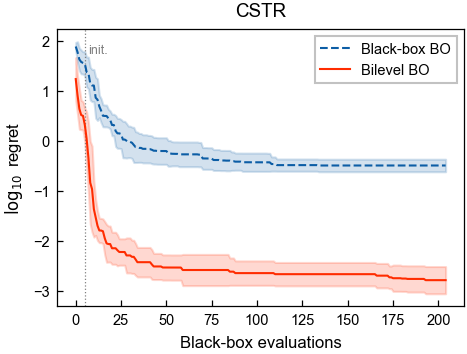

In [14]:
# ── Figure 2: CSTR Hero Convergence ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(COL1, 2.4))

res = xibest_data[5]['results']
prob = res['CSTR']
n_init_here = xibest_data[5]['settings']['n_initial']

plot_regret_curve(ax, prob['blackbox_bo_ei']['regrets'], C_BBBO, 'Black-box BO', ls='--')
plot_regret_curve(ax, prob['bilevel_bo_ei']['regrets'], C_BIBO, 'Bilevel BO')

ax.axvline(n_init_here, color='0.5', ls=':', lw=0.6, zorder=1)
ax.text(n_init_here + 2, ax.get_ylim()[1] - 0.3, 'init.', fontsize=6, color='0.5', va='top')

ax.set_xlabel('Black-box evaluations')
ax.set_ylabel(r'$\log_{10}$ regret')
ax.set_title('CSTR')
ax.legend(frameon=True, fancybox=False, edgecolor='0.7', loc='upper right')

save_fig(fig, 'cstr_convergence')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved convergence_grid.eps/.pdf


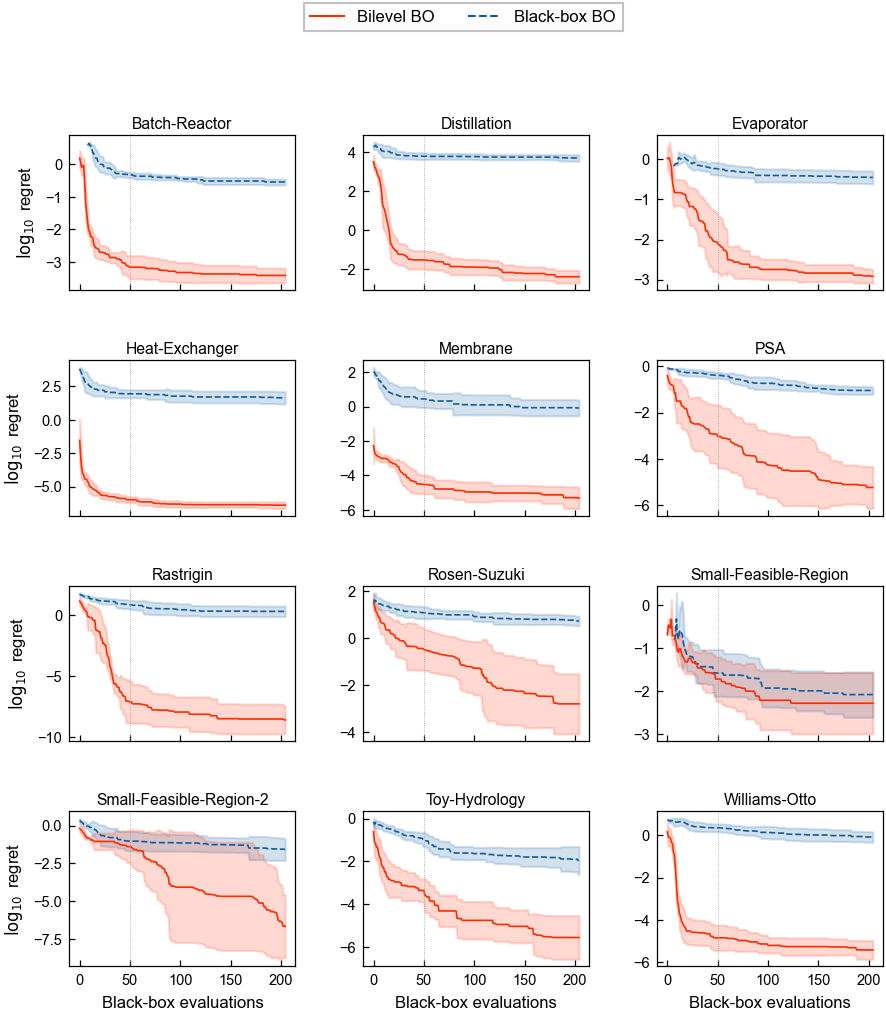

In [15]:
# ── Figure 3: 12-Panel Convergence Grid ──────────────────────────────────────
other_probs = [p for p in problem_names if p != 'CSTR']
nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(COL2, 7.2))

res = xibest_data[5]['results']
n_init_here = xibest_data[50]['settings']['n_initial']

for idx, pname in enumerate(other_probs):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]
    prob = res[pname]

    plot_regret_curve(ax, prob['blackbox_bo_ei']['regrets'], C_BBBO, 'BB-BO', ls='--', lw=0.8)
    plot_regret_curve(ax, prob['bilevel_bo_ei']['regrets'], C_BIBO, 'Bi-BO', lw=0.8)

    ax.axvline(n_init_here, color='0.6', ls=':', lw=0.4)
    ax.set_title(pname, fontsize=7.5, pad=3)
    if r == nrows - 1:
        ax.set_xlabel('Black-box evaluations')
    else:
        ax.set_xticklabels([])
    if c == 0:
        ax.set_ylabel(r'$\log_{10}$ regret')

legend_elements = [
    Line2D([0], [0], color=C_BIBO, ls='-', lw=1.0, label='Bilevel BO'),
    Line2D([0], [0], color=C_BBBO, ls='--', lw=1.0, label='Black-box BO'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
           frameon=True, fancybox=False, edgecolor='0.7',
           bbox_to_anchor=(0.5, 1.01), fontsize=8)

fig.subplots_adjust(hspace=0.45, wspace=0.30)
save_fig(fig, 'convergence_grid')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved scatter_bb_vs_bi.eps/.pdf


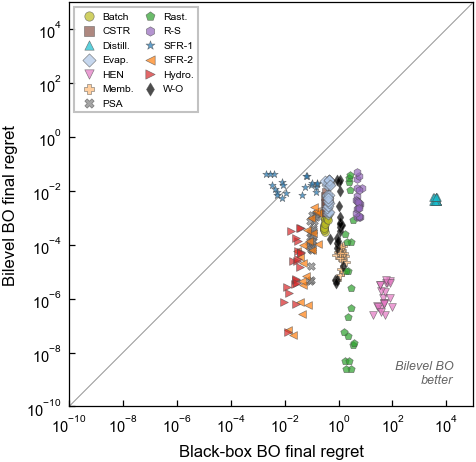

In [16]:
# ── Figure 4: BB-BO vs Bi-BO Scatter ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(COL1, COL1))

scatter_pts = defaultdict(list)
for (ni, xi), d in all_data_merged.items():
    results = d['results']
    for pname in problem_names:
        bb_finals = [r[-1] for r in results[pname]['blackbox_bo_ei']['regrets']
                     if np.isfinite(r[-1])]
        bi_finals = [r[-1] for r in results[pname]['bilevel_bo_ei']['regrets']
                     if np.isfinite(r[-1])]
        if bb_finals and bi_finals:
            bb_med = max(np.median(np.abs(bb_finals)), 1e-10)
            bi_med = max(np.median(np.abs(bi_finals)), 1e-10)
            scatter_pts[pname].append((bb_med, bi_med))

for pname in problem_names:
    pts = scatter_pts[pname]
    if not pts:
        continue
    bb_vals, bi_vals = zip(*pts)
    ax.scatter(bb_vals, bi_vals, s=14, alpha=0.7,
               color=PROB_COLORS[pname], marker=PROB_MARKERS[pname],
               label=PROB_META[pname]['short'],
               linewidths=0.3, edgecolors='0.3', zorder=3)

lims = [1e-10, 1e5]
ax.plot(lims, lims, 'k-', lw=0.5, alpha=0.4, zorder=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.set_xlabel('Black-box BO final regret')
ax.set_ylabel('Bilevel BO final regret')
ax.text(0.95, 0.05, 'Bilevel BO\nbetter', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=6, fontstyle='italic', color='0.4')
ax.legend(fontsize=5, ncol=2, frameon=True, fancybox=False, edgecolor='0.7',
          loc='upper left', handletextpad=0.3, columnspacing=0.5, markerscale=1.2)

save_fig(fig, 'scatter_bb_vs_bi')
plt.show()

  Saved dimensionality_scaling.eps/.pdf


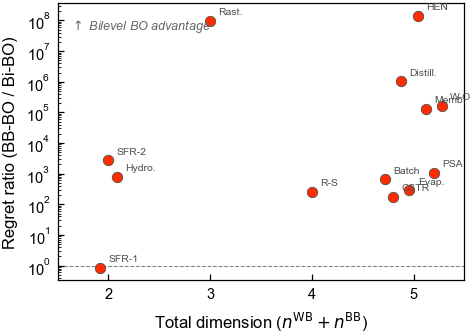

In [17]:
# ── Figure 5: Dimensionality Scaling ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(COL1, 2.4))

res = xibest_data[5]['results']
dims, ratios, labels_dim = [], [], []

for pname in problem_names:
    prob = res[pname]
    bb_final = [r[-1] for r in prob['blackbox_bo_ei']['regrets'] if np.isfinite(r[-1])]
    bi_final = [r[-1] for r in prob['bilevel_bo_ei']['regrets'] if np.isfinite(r[-1])]
    if not bb_final or not bi_final:
        continue
    bb_mean = np.mean(np.abs(bb_final))
    bi_mean = max(np.mean(np.abs(bi_final)), 1e-12)
    ratio = bb_mean / bi_mean
    dims.append(PROB_META[pname]['total'])
    ratios.append(ratio)
    labels_dim.append(PROB_META[pname]['short'])

# Jitter overlapping x values
x_jit = np.array(dims, dtype=float)
for i in range(len(x_jit)):
    same = [j for j in range(i) if dims[j] == dims[i]]
    total_same = sum(1 for d in dims if d == dims[i])
    x_jit[i] += (len(same) - (total_same - 1) / 2) * 0.08

ax.scatter(x_jit, ratios, s=25, color=C_BIBO, zorder=3,
           edgecolors='0.3', linewidths=0.4)
for xi, yi, lbl in zip(x_jit, ratios, labels_dim):
    ax.annotate(lbl, (xi, yi), textcoords='offset points', xytext=(4, 3),
                fontsize=5, color='0.3')

ax.set_yscale('log')
ax.axhline(1, color='0.5', ls='--', lw=0.5, zorder=1)
ax.set_xlabel(r'Total dimension ($n^{\mathrm{WB}} + n^{\mathrm{BB}}$)')
ax.set_ylabel('Regret ratio (BB-BO / Bi-BO)')
ax.set_xticks([2, 3, 4, 5])
ax.set_xlim(1.5, 5.5)
ax.text(0.03, 0.95, r'$\uparrow$ Bilevel BO advantage', transform=ax.transAxes,
        fontsize=6, fontstyle='italic', color='0.4', va='top')

save_fig(fig, 'dimensionality_scaling')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved ninit_robustness.eps/.pdf


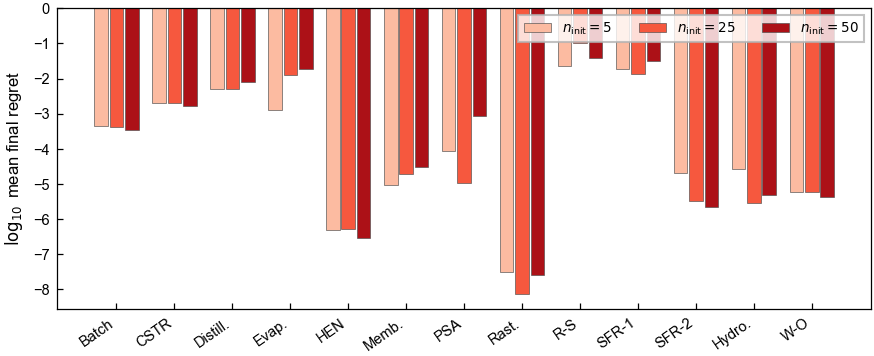

In [18]:
# ── Figure 6: n_init Robustness Bars ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(COL2, 2.6))

n_probs = len(problem_names)
n_groups = len(ninit_values)
bar_width = 0.8 / n_groups
x_base = np.arange(n_probs)

cmap_ninit = plt.cm.Reds(np.linspace(0.25, 0.85, n_groups))

for gi, ni in enumerate(ninit_values):
    res = xibest_data[ni]['results']
    log_regrets = []
    for pname in problem_names:
        r_final = [r[-1] for r in res[pname]['bilevel_bo_ei']['regrets']
                   if np.isfinite(r[-1])]
        val = np.mean(np.abs(r_final)) if r_final else np.inf
        log_regrets.append(np.log10(max(val, 1e-12)))
    offset = (gi - (n_groups - 1) / 2) * bar_width
    ax.bar(x_base + offset, log_regrets, width=bar_width * 0.88,
           color=cmap_ninit[gi], edgecolor='0.3', linewidth=0.3,
           label=f'$n_{{\\mathrm{{init}}}} = {ni}$')

ax.set_xticks(x_base)
ax.set_xticklabels(SHORT_NAMES, rotation=35, ha='right')
ax.set_ylabel(r'$\log_{10}$ mean final regret')
ax.legend(ncol=4, frameon=True, fancybox=False, edgecolor='0.7',
          loc='upper right', fontsize=6.5)

save_fig(fig, 'ninit_robustness')
plt.show()

  Saved xi_heatmap.eps/.pdf


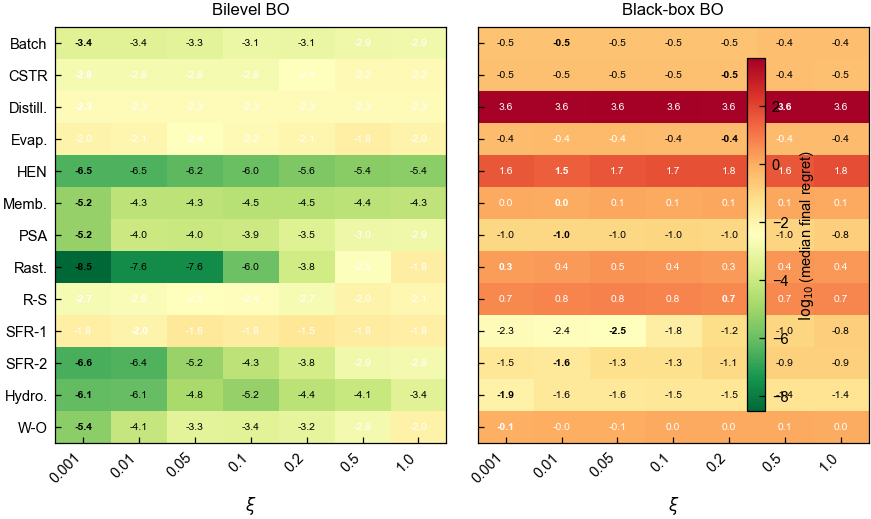

In [19]:
# ── Figure 7: Xi Sensitivity Heatmaps ────────────────────────────────────────
fig, (ax_bi, ax_bb) = plt.subplots(1, 2, figsize=(COL2, 3.6), sharey=True)

bi_matrix = np.full((len(problem_names), len(xi_values)), np.nan)
bb_matrix = np.full((len(problem_names), len(xi_values)), np.nan)

for pi, pname in enumerate(problem_names):
    for xi_idx, xi in enumerate(xi_values):
        bi_finals, bb_finals = [], []
        for ni in ninit_values:
            if (ni, xi) not in all_data_merged:
                continue
            results = all_data_merged[(ni, xi)]['results']
            bi_finals.extend([np.abs(r[-1]) for r in results[pname]['bilevel_bo_ei']['regrets']
                              if np.isfinite(r[-1])])
            bb_finals.extend([np.abs(r[-1]) for r in results[pname]['blackbox_bo_ei']['regrets']
                              if np.isfinite(r[-1])])
        if bi_finals:
            bi_matrix[pi, xi_idx] = np.log10(max(np.median(bi_finals), 1e-10))
        if bb_finals:
            bb_matrix[pi, xi_idx] = np.log10(max(np.median(bb_finals), 1e-10))

vmin = min(np.nanmin(bi_matrix), np.nanmin(bb_matrix))
vmax = max(np.nanmax(bi_matrix), np.nanmax(bb_matrix))
xi_labels = [f'{x}' for x in xi_values]

# Bilevel BO
im = ax_bi.imshow(bi_matrix, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax)
ax_bi.set_xticks(range(len(xi_values)))
ax_bi.set_xticklabels(xi_labels, rotation=45, ha='right')
ax_bi.set_yticks(range(len(problem_names)))
ax_bi.set_yticklabels(SHORT_NAMES)
ax_bi.set_xlabel(r'$\xi$')
ax_bi.set_title('Bilevel BO', fontsize=8)

for i in range(len(problem_names)):
    best_j = np.nanargmin(bi_matrix[i, :])
    for j in range(len(xi_values)):
        val = bi_matrix[i, j]
        if np.isfinite(val):
            weight = 'bold' if j == best_j else 'normal'
            clr = 'white' if val > np.nanmedian(bi_matrix) else 'black'
            ax_bi.text(j, i, f'{val:.1f}', ha='center', va='center',
                       fontsize=5, fontweight=weight, color=clr)

# Black-box BO
ax_bb.imshow(bb_matrix, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax)
ax_bb.set_xticks(range(len(xi_values)))
ax_bb.set_xticklabels(xi_labels, rotation=45, ha='right')
ax_bb.set_xlabel(r'$\xi$')
ax_bb.set_title('Black-box BO', fontsize=8)

for i in range(len(problem_names)):
    best_j = np.nanargmin(bb_matrix[i, :])
    for j in range(len(xi_values)):
        val = bb_matrix[i, j]
        if np.isfinite(val):
            weight = 'bold' if j == best_j else 'normal'
            clr = 'white' if val > np.nanmedian(bb_matrix) else 'black'
            ax_bb.text(j, i, f'{val:.1f}', ha='center', va='center',
                       fontsize=5, fontweight=weight, color=clr)

cbar = fig.colorbar(im, ax=[ax_bi, ax_bb], shrink=0.85, pad=0.03)
cbar.set_label(r'$\log_{10}$(median final regret)', fontsize=7)

fig.subplots_adjust(wspace=0.08)
save_fig(fig, 'xi_heatmap')
plt.show()

---
## 5. New Statistical Figures

In [20]:
# # ── Forest Plot of Effect Sizes ───────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(COL1, 4.0))

# # Bootstrap 95% CI for rank-biserial r
# res = xibest_data[5]['results']
# n_boot = 100
# rng = np.random.default_rng(42)

# effect_data = []
# for pname in problem_names:
#     prob = res[pname]
#     bb_f = np.array([r[-1] for r in prob['blackbox_bo_ei']['regrets']])
#     bi_f = np.array([r[-1] for r in prob['bilevel_bo_ei']['regrets']])
#     bb_f = np.where(np.isfinite(bb_f), bb_f, np.nan)
#     bi_f = np.where(np.isfinite(bi_f), bi_f, np.nan)
#     valid = np.isfinite(bb_f) & np.isfinite(bi_f)
#     bb_v, bi_v = bb_f[valid], bi_f[valid]
#     n = len(bb_v)

#     # Bootstrap
#     boot_r = []
#     for _ in range(n_boot):
#         idx = rng.choice(n, n, replace=True)
#         d = bb_v[idx] - bi_v[idx]
#         d = d[d != 0]
#         if len(d) >= 2:
#             try:
#                 w, _ = wilcoxon(d)
#                 r_b = 1.0 - (2.0 * w) / (len(d) * (len(d) + 1) / 2)
#                 boot_r.append(r_b)
#             except ValueError:
#                 pass
#     if boot_r:
#         ci_lo = np.percentile(boot_r, 2.5)
#         ci_hi = np.percentile(boot_r, 97.5)
#     else:
#         ci_lo = ci_hi = 0.0

#     row = df_stats[df_stats['problem'] == pname].iloc[0]
#     effect_data.append({
#         'short': PROB_META[pname]['short'],
#         'r_rb': row['r_rb'],
#         'ci_lo': ci_lo, 'ci_hi': ci_hi,
#         'sig': row['significant'],
#         'p_adj': row['p_adjusted'],
#     })

# # Sort by effect size
# effect_data.sort(key=lambda x: x['r_rb'])
# y_pos = np.arange(len(effect_data))

# for i, ed in enumerate(effect_data):
#     color = C_BIBO if ed['sig'] else '0.6'
#     ax.errorbar(ed['r_rb'], i, xerr=[[ed['r_rb'] - ed['ci_lo']], [ed['ci_hi'] - ed['r_rb']]],
#                 fmt='o', color=color, markersize=4, capsize=2, capthick=0.6, elinewidth=0.6)
#     ax.text(1.05, i, f"p={ed['p_adj']:.3f}", fontsize=5, va='center',
#             transform=ax.get_yaxis_transform(), color='0.4')

# ax.axvline(0, color='0.5', ls='--', lw=0.5)
# ax.set_yticks(y_pos)
# ax.set_yticklabels([ed['short'] for ed in effect_data])
# ax.set_xlabel('Rank-biserial $r$ (BB-BO vs Bi-BO)')
# ax.set_title('Effect Size Forest Plot', fontsize=9)
# ax.set_xlim(-0.2, 1.2)

# save_fig(fig, 'effect_size_forest')
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved regret_boxplots.eps/.pdf


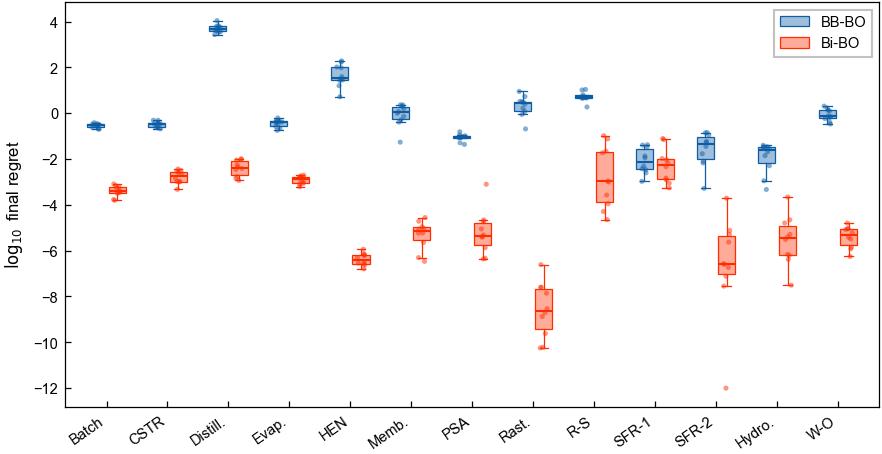

In [21]:
# ── Boxplot of Final Regret Distributions ────────────────────────────────────
fig, ax = plt.subplots(figsize=(COL2, 3.5))

res = xibest_data[5]['results']
positions = []
box_data_bb = []
box_data_bi = []

for pi, pname in enumerate(problem_names):
    prob = res[pname]
    bb_f = np.array([np.abs(r[-1]) for r in prob['blackbox_bo_ei']['regrets']
                     if np.isfinite(r[-1])])
    bi_f = np.array([np.abs(r[-1]) for r in prob['bilevel_bo_ei']['regrets']
                     if np.isfinite(r[-1])])
    bb_f = np.log10(np.clip(bb_f, 1e-12, None))
    bi_f = np.log10(np.clip(bi_f, 1e-12, None))
    box_data_bb.append(bb_f)
    box_data_bi.append(bi_f)

x = np.arange(len(problem_names))
w = 0.35

bp_bb = ax.boxplot(box_data_bb, positions=x - w/2, widths=w * 0.8,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=_lighten(C_BBBO, 0.6), edgecolor=C_BBBO, linewidth=0.6),
                   medianprops=dict(color=C_BBBO, linewidth=1.0),
                   whiskerprops=dict(color=C_BBBO, linewidth=0.6),
                   capprops=dict(color=C_BBBO, linewidth=0.6))

bp_bi = ax.boxplot(box_data_bi, positions=x + w/2, widths=w * 0.8,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=_lighten(C_BIBO, 0.6), edgecolor=C_BIBO, linewidth=0.6),
                   medianprops=dict(color=C_BIBO, linewidth=1.0),
                   whiskerprops=dict(color=C_BIBO, linewidth=0.6),
                   capprops=dict(color=C_BIBO, linewidth=0.6))

# Jittered scatter overlay
rng = np.random.default_rng(0)
for pi in range(len(problem_names)):
    jit = rng.uniform(-0.06, 0.06, len(box_data_bb[pi]))
    ax.scatter(x[pi] - w/2 + jit, box_data_bb[pi], s=6, color=C_BBBO, alpha=0.5, zorder=3, edgecolors='none')
    jit = rng.uniform(-0.06, 0.06, len(box_data_bi[pi]))
    ax.scatter(x[pi] + w/2 + jit, box_data_bi[pi], s=6, color=C_BIBO, alpha=0.5, zorder=3, edgecolors='none')

ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, rotation=35, ha='right')
ax.set_ylabel(r'$\log_{10}$ final regret')
ax.legend([bp_bb['boxes'][0], bp_bi['boxes'][0]], ['BB-BO', 'Bi-BO'],
          loc='upper right', frameon=True, fancybox=False, edgecolor='0.7')

save_fig(fig, 'regret_boxplots')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved wall_time_comparison.eps/.pdf


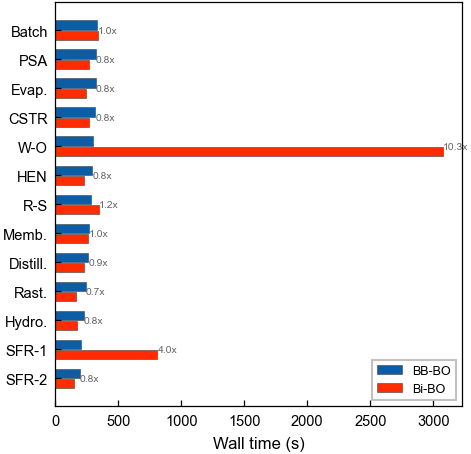

In [22]:
# ── Wall Time Comparison Bars ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(COL1, 3.5))

# Sort by BB-BO time descending
df_t_sorted = df_time.sort_values('bb_time_mean', ascending=True)
y = np.arange(len(df_t_sorted))
h = 0.35

ax.barh(y + h/2, df_t_sorted['bb_time_mean'], height=h * 0.9,
        color=C_BBBO, edgecolor='0.3', linewidth=0.3, label='BB-BO')
ax.barh(y - h/2, df_t_sorted['bi_time_mean'], height=h * 0.9,
        color=C_BIBO, edgecolor='0.3', linewidth=0.3, label='Bi-BO')

# Annotate ratio
for i, (_, row) in enumerate(df_t_sorted.iterrows()):
    xmax = max(row['bb_time_mean'], row['bi_time_mean'])
    ax.text(xmax + 0.5, y[i], f'{row["time_ratio"]:.1f}x', fontsize=5,
            va='center', color='0.4')

ax.set_yticks(y)
ax.set_yticklabels(df_t_sorted['short'])
ax.set_xlabel('Wall time (s)')
ax.legend(frameon=True, fancybox=False, edgecolor='0.7', fontsize=6, loc='lower right')

save_fig(fig, 'wall_time_comparison')
plt.show()

  Saved significance_matrix.eps/.pdf


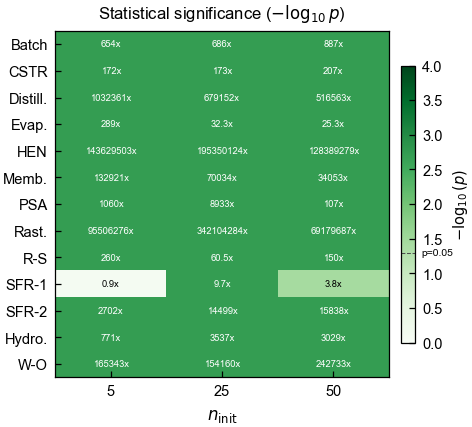

In [23]:
# ── Significance Matrix: rows=problems, cols=n_init ──────────────────────────
fig, ax = plt.subplots(figsize=(COL1, 3.0))

sig_matrix = np.full((len(problem_names), len(ninit_values)), np.nan)
ratio_matrix = np.full((len(problem_names), len(ninit_values)), np.nan)

for ni_idx, ni in enumerate(ninit_values):
    res = xibest_data[ni]['results']
    for pi, pname in enumerate(problem_names):
        prob = res[pname]
        bb_f = np.array([r[-1] for r in prob['blackbox_bo_ei']['regrets']])
        bi_f = np.array([r[-1] for r in prob['bilevel_bo_ei']['regrets']])
        bb_f = np.where(np.isfinite(bb_f), bb_f, np.nan)
        bi_f = np.where(np.isfinite(bi_f), bi_f, np.nan)
        valid = np.isfinite(bb_f) & np.isfinite(bi_f)
        bb_v, bi_v = bb_f[valid], bi_f[valid]

        if len(bb_v) >= 5 and not np.allclose(bb_v, bi_v):
            _, p = wilcoxon(bb_v, bi_v, alternative='two-sided')
            sig_matrix[pi, ni_idx] = -np.log10(max(p, 1e-10))
        else:
            sig_matrix[pi, ni_idx] = 0

        bb_m = np.nanmean(np.abs(bb_v))
        bi_m = max(np.nanmean(np.abs(bi_v)), 1e-15)
        ratio_matrix[pi, ni_idx] = bb_m / bi_m

im = ax.imshow(sig_matrix, aspect='auto', cmap='Greens', vmin=0, vmax=4)
ax.set_xticks(range(len(ninit_values)))
ax.set_xticklabels([str(ni) for ni in ninit_values])
ax.set_yticks(range(len(problem_names)))
ax.set_yticklabels(SHORT_NAMES)
ax.set_xlabel(r'$n_{\mathrm{init}}$')
ax.set_title('Statistical significance ($-\\log_{10} p$)', fontsize=8)

for i in range(len(problem_names)):
    for j in range(len(ninit_values)):
        ratio = ratio_matrix[i, j]
        sig_val = sig_matrix[i, j]
        clr = 'white' if sig_val > 2.5 else 'black'
        if ratio >= 100:
            txt = f'{ratio:.0f}x'
        else:
            txt = f'{ratio:.1f}x'
        ax.text(j, i, txt, ha='center', va='center', fontsize=4.5, color=clr)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.03)
cbar.set_label(r'$-\log_{10}(p)$', fontsize=7)
# Mark significance thresholds
cbar.ax.axhline(y=-np.log10(0.05), color='0.3', ls='--', lw=0.5)
cbar.ax.text(1.5, -np.log10(0.05), 'p=0.05', fontsize=5, va='center')

save_fig(fig, 'significance_matrix')
plt.show()

---
## 6. Presentation Figures (from TWCCC)

Presentation-quality versions of key figures using `presentation.mplstyle`.
Includes summary table, CSTR variable estimates, convergence speed,
evaluation efficiency, and search space animations.

  Saved summary_table.eps/.pdf


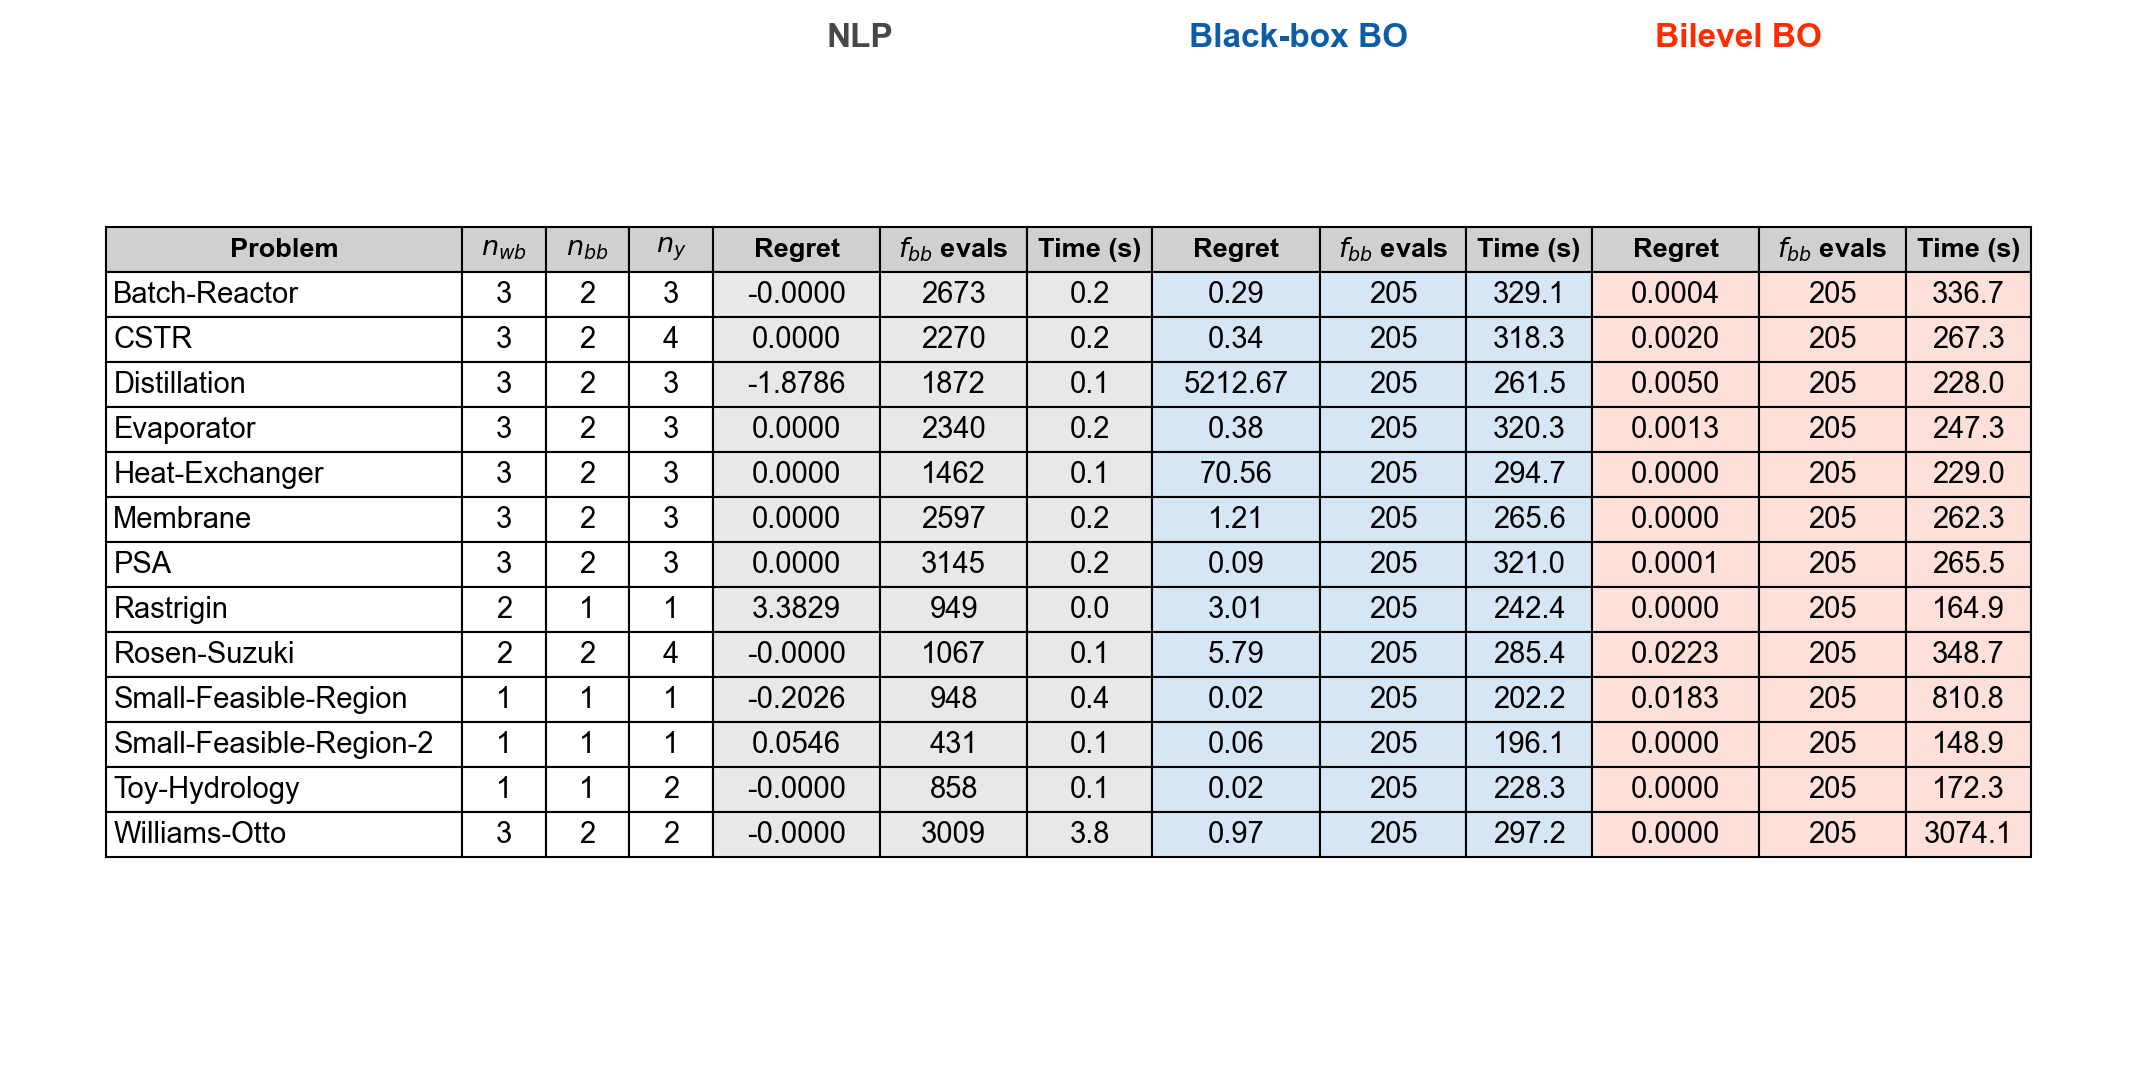

In [24]:
# ── Publication-style summary table figure ────────────────────────────────────
PRES_STYLE = REPO_ROOT / 'presentation.mplstyle'

res_pres = xibest_data[5]['results']
table_rows = []
for pname in problem_names:
    prob = res_pres[pname]
    p = all_probs[pname]

    def _tbl_stats(solver_key, is_nlp=False):
        s = prob[solver_key]
        if is_nlp:
            regrets = np.array(s['final_regrets'])
        else:
            regrets = np.array([r[-1] for r in s['regrets'] if np.isfinite(r[-1])])
        fbb = np.array(s['n_fbb_evals'])
        wt  = np.array(s['wall_times'])
        return (np.mean(regrets) if len(regrets) else np.inf,
                np.mean(fbb), np.mean(wt))

    nlp_reg, nlp_fbb, nlp_wt = _tbl_stats('multistart_slsqp', is_nlp=True)
    bb_reg,  bb_fbb,  bb_wt  = _tbl_stats('blackbox_bo_ei')
    bi_reg,  bi_fbb,  bi_wt  = _tbl_stats('bilevel_bo_ei')

    table_rows.append({
        'Problem': pname, 'n_wb': p.n_x_wb, 'n_bb': p.n_x_bb, 'n_y': p.n_y,
        'NLP regret': nlp_reg, 'NLP f_bb': nlp_fbb, 'NLP time': nlp_wt,
        'BB-BO regret': bb_reg, 'BB-BO f_bb': bb_fbb, 'BB-BO time': bb_wt,
        'Bi-BO regret': bi_reg, 'Bi-BO f_bb': bi_fbb, 'Bi-BO time': bi_wt,
    })

with plt.style.context(str(PRES_STYLE)):
    fig, ax = plt.subplots(figsize=(18, 9))
    ax.axis('off')

    col_labels = [
        'Problem', '$n_{wb}$', '$n_{bb}$', '$n_y$',
        'Regret', '$f_{bb}$ evals', 'Time (s)',
        'Regret', '$f_{bb}$ evals', 'Time (s)',
        'Regret', '$f_{bb}$ evals', 'Time (s)',
    ]

    cell_text = []
    for r in table_rows:
        cell_text.append([
            r['Problem'],
            f"{r['n_wb']}", f"{r['n_bb']}", f"{r['n_y']}",
            f"{r['NLP regret']:.4f}", f"{r['NLP f_bb']:.0f}", f"{r['NLP time']:.1f}",
            f"{r['BB-BO regret']:.2f}", f"{r['BB-BO f_bb']:.0f}", f"{r['BB-BO time']:.1f}",
            f"{r['Bi-BO regret']:.4f}", f"{r['Bi-BO f_bb']:.0f}", f"{r['Bi-BO time']:.1f}",
        ])

    table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.0, 1.8)

    col_widths = [0.17, 0.04, 0.04, 0.04,
                  0.08, 0.07, 0.06, 0.08, 0.07, 0.06, 0.08, 0.07, 0.06]
    for row_idx in range(len(cell_text) + 1):
        for col_idx, cw in enumerate(col_widths):
            table[row_idx, col_idx].set_width(cw)

    for j in range(len(col_labels)):
        cell = table[0, j]
        cell.set_facecolor('#d0d0d0')
        cell.set_text_props(weight='bold', fontsize=13)

    solver_colors = {
        (4, 5, 6): '#e8e8e8',
        (7, 8, 9): '#d6e6f5',
        (10, 11, 12): '#fde0d9',
    }
    for row_idx in range(1, len(cell_text) + 1):
        for cols, color in solver_colors.items():
            for c in cols:
                table[row_idx, c].set_facecolor(color)

    for row_idx in range(1, len(cell_text) + 1):
        table[row_idx, 0].set_text_props(ha='left')
        table[row_idx, 0].PAD = 0.02

    ax.text(0.40, 0.97, 'NLP', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=16, fontweight='bold', color=C_NLP)
    ax.text(0.61, 0.97, 'Black-box BO', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=16, fontweight='bold', color=C_BBBO)
    ax.text(0.82, 0.97, 'Bilevel BO', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=16, fontweight='bold', color=C_BIBO)

    save_fig(fig, 'summary_table')
    plt.show()

In [25]:
# ── CSTR: Best estimates of process & catalyst variables ──────────────────────
res_pres = xibest_data[5]['results']
cstr = res_pres['CSTR']
J_opt = cstr['J_optimal']
maximize = cstr['maximize']

var_names_wb = ['T (K)', 'P (bar)', r'$\tau$ (s)']
var_names_bb = [r'$E_b$ (eV)', r'$\Delta E_a$']
known_opt_wb = [647.25, 20.0, 5.0]
known_opt_bb = [-1.047, 0.2]

# Black-box BO
bb = cstr['blackbox_bo_ei']
n_reps_cstr = len(bb['X_history'])
bb_best_wb, bb_best_bb, bb_best_J = [], [], []
for rep in range(n_reps_cstr):
    Y = np.array(bb['Y_history'][rep])
    X = np.array(bb['X_history'][rep])
    idx = np.argmax(Y) if maximize else np.argmin(Y)
    bb_best_J.append(Y[idx])
    bb_best_wb.append(X[idx, :3])
    bb_best_bb.append(X[idx, 3:])
bb_best_wb = np.array(bb_best_wb)
bb_best_bb = np.array(bb_best_bb)
bb_best_J  = np.array(bb_best_J)

# Bilevel BO
bi = cstr['bilevel_bo_ei']
bi_best_wb, bi_best_bb, bi_best_J = [], [], []
for rep in range(n_reps_cstr):
    Y = np.array(bi['Y_history'][rep])
    X_bb = np.array(bi['X_bb_history'][rep])
    X_wb = bi['X_wb_history'][rep]
    idx = np.argmax(Y) if maximize else np.argmin(Y)
    bi_best_J.append(Y[idx])
    bi_best_bb.append(X_bb[idx])
    bi_best_wb.append(X_wb[idx])
bi_best_wb = np.array(bi_best_wb)
bi_best_bb = np.array(bi_best_bb)
bi_best_J  = np.array(bi_best_J)

header = (f'{"Variable":<16s} {"Known opt":>12s} {"BB-BO mean":>12s} '
          f'{"BB-BO std":>10s} {"Bi-BO mean":>12s} {"Bi-BO std":>10s}')
print(header)
print('-' * len(header))
for i, name in enumerate(var_names_wb):
    print(f'{name:<16s} {known_opt_wb[i]:>12.3f} '
          f'{bb_best_wb[:, i].mean():>12.3f} {bb_best_wb[:, i].std():>10.3f} '
          f'{bi_best_wb[:, i].mean():>12.3f} {bi_best_wb[:, i].std():>10.3f}')
for i, name in enumerate(var_names_bb):
    print(f'{name:<16s} {known_opt_bb[i]:>12.3f} '
          f'{bb_best_bb[:, i].mean():>12.3f} {bb_best_bb[:, i].std():>10.3f} '
          f'{bi_best_bb[:, i].mean():>12.3f} {bi_best_bb[:, i].std():>10.3f}')
print(f'{"J (% yield)":<16s} {J_opt:>12.3f} '
      f'{bb_best_J.mean():>12.3f} {bb_best_J.std():>10.3f} '
      f'{bi_best_J.mean():>12.3f} {bi_best_J.std():>10.3f}')

Variable            Known opt   BB-BO mean  BB-BO std   Bi-BO mean  Bi-BO std
-----------------------------------------------------------------------------
T (K)                 647.250      652.873      7.198      647.496      0.551
P (bar)                20.000       19.586      0.380       20.000      0.000
$\tau$ (s)              5.000        4.801      0.146        5.000      0.000
$E_b$ (eV)             -1.047       -1.044      0.034       -1.045      0.004
$\Delta E_a$            0.200        0.192      0.007        0.200      0.000
J (% yield)            92.324       91.988      0.096       92.322      0.001


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved convergence_speed.eps/.pdf


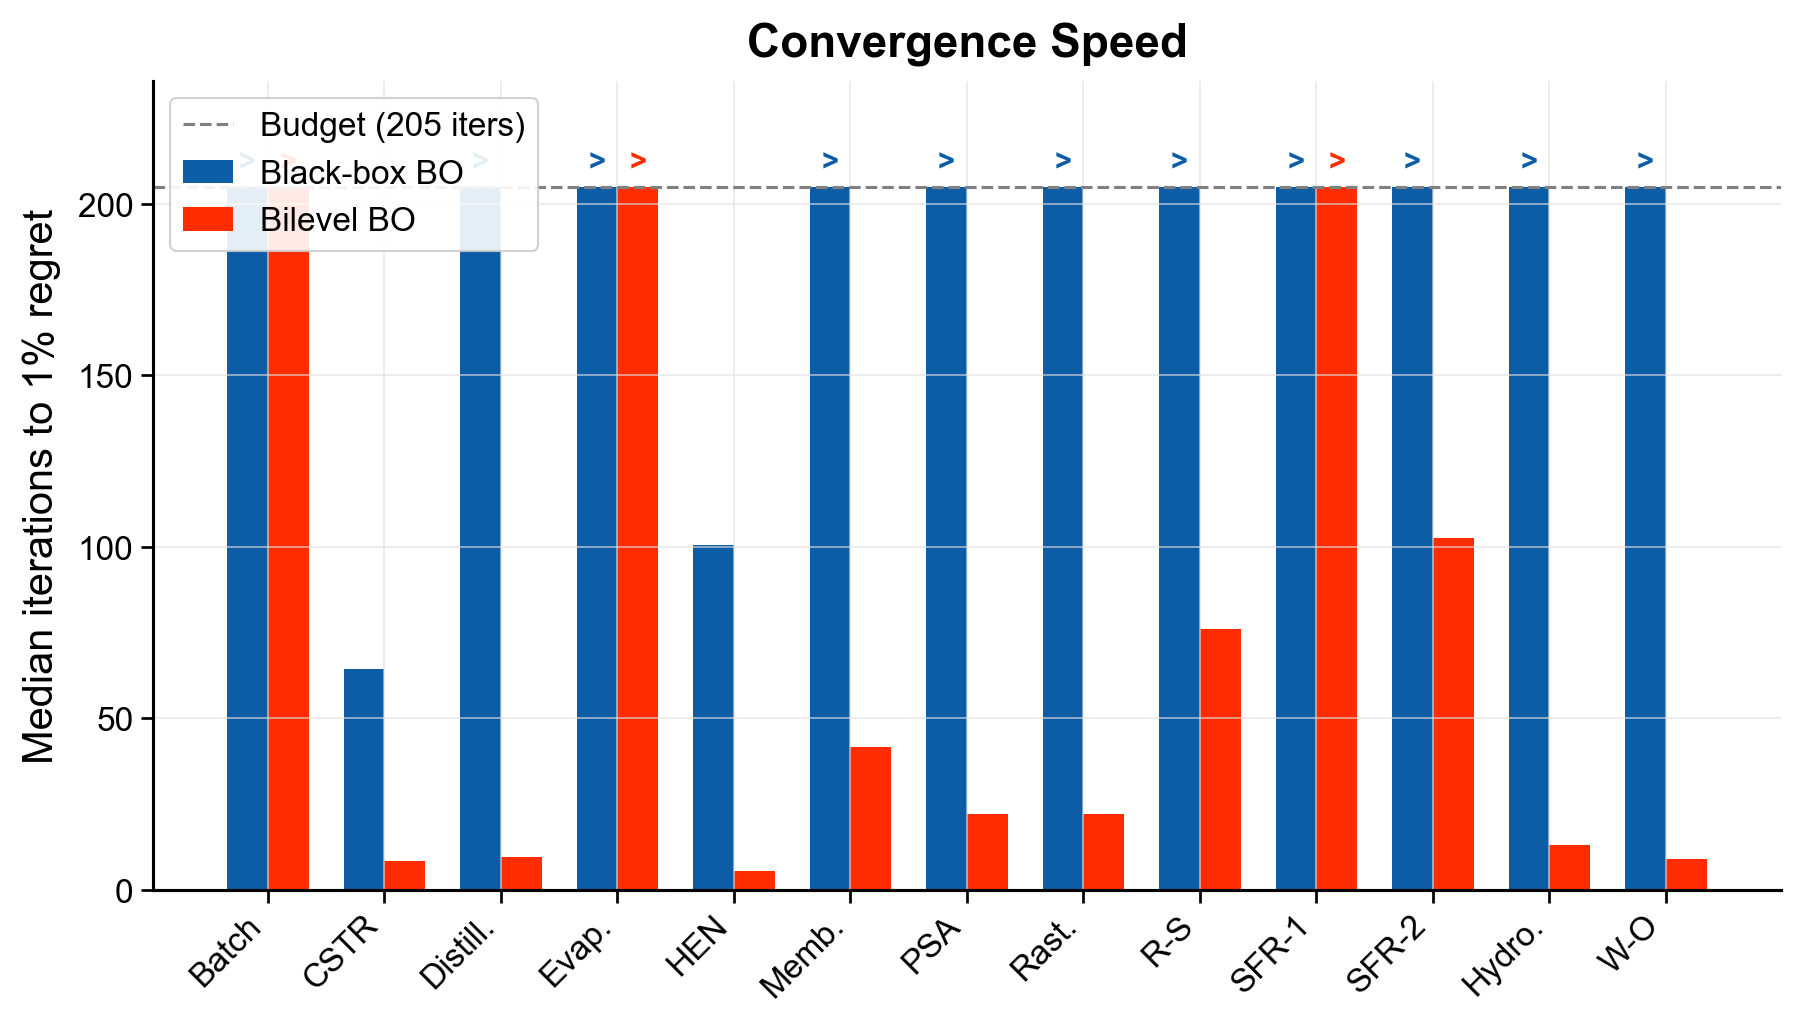

In [26]:
# ── Convergence Speed: Iterations to 1% Target ───────────────────────────────
def iters_to_threshold(regret_list, frac=0.01):
    """Median iterations to reach frac * initial regret across reps."""
    counts = []
    for r in regret_list:
        r = np.asarray(r)
        if not np.isfinite(r[0]) or r[0] <= 0:
            counts.append(len(r))
            continue
        target = frac * r[0]
        hits = np.where(r <= target)[0]
        counts.append(int(hits[0]) if len(hits) else len(r))
    return np.median(counts)

res_pres = xibest_data[5]['results']
n_budget = xibest_data[5]['settings']['n_iterations'] + xibest_data[5]['settings']['n_initial']

bb_iters, bi_iters = [], []
for pname in problem_names:
    prob = res_pres[pname]
    bb_iters.append(iters_to_threshold(prob['blackbox_bo_ei']['regrets']))
    bi_iters.append(iters_to_threshold(prob['bilevel_bo_ei']['regrets']))
bb_iters = np.array(bb_iters)
bi_iters = np.array(bi_iters)

with plt.style.context(str(PRES_STYLE)):
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(problem_names))
    w = 0.35

    ax.bar(x - w/2, bb_iters, w, color=C_BBBO, label='Black-box BO')
    ax.bar(x + w/2, bi_iters, w, color=C_BIBO, label='Bilevel BO')
    ax.axhline(n_budget, color='grey', ls='--', lw=1.5, label=f'Budget ({n_budget} iters)')

    for i, (bb, bi) in enumerate(zip(bb_iters, bi_iters)):
        if bb >= n_budget:
            ax.text(i - w/2, n_budget + 3, '>', ha='center', va='bottom',
                    fontsize=14, fontweight='bold', color=C_BBBO)
        if bi >= n_budget:
            ax.text(i + w/2, n_budget + 3, '>', ha='center', va='bottom',
                    fontsize=14, fontweight='bold', color=C_BIBO)

    ax.set_ylabel('Median iterations to 1% regret')
    ax.set_xticks(x)
    ax.set_xticklabels([PROB_META[p]['short'] for p in problem_names],
                       rotation=45, ha='right')
    ax.set_ylim(0, n_budget * 1.15)
    ax.legend(loc='upper left')
    ax.set_title('Convergence Speed')

    save_fig(fig, 'convergence_speed')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved fbb_evaluations.eps/.pdf


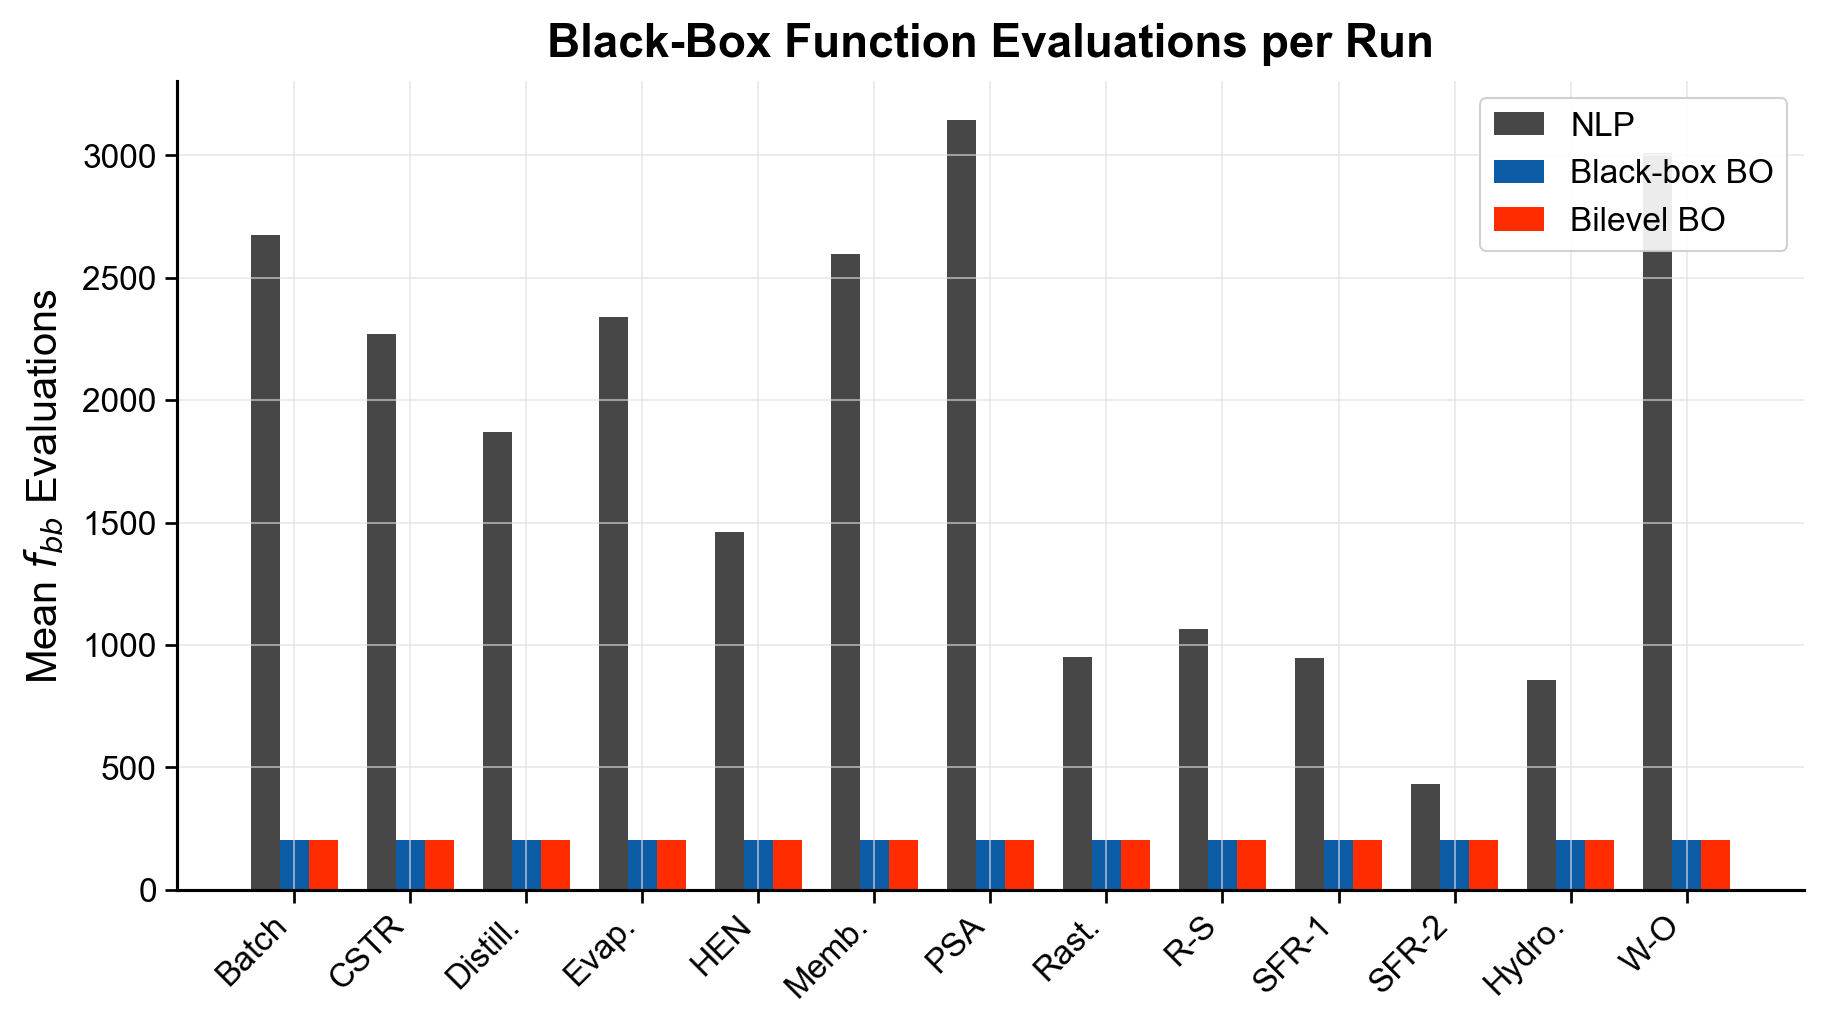

In [27]:
# ── Black-Box Function Evaluation Efficiency ──────────────────────────────────
res_pres = xibest_data[5]['results']

with plt.style.context(str(PRES_STYLE)):
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(problem_names))
    w = 0.25

    nlp_fbb, bb_fbb, bi_fbb = [], [], []
    for pname in problem_names:
        prob = res_pres[pname]
        nlp_fbb.append(np.mean(prob['multistart_slsqp']['n_fbb_evals']))
        bb_fbb.append(np.mean(prob['blackbox_bo_ei']['n_fbb_evals']))
        bi_fbb.append(np.mean(prob['bilevel_bo_ei']['n_fbb_evals']))

    ax.bar(x - w, nlp_fbb, w, color=C_NLP, label='NLP')
    ax.bar(x,     bb_fbb,  w, color=C_BBBO, label='Black-box BO')
    ax.bar(x + w, bi_fbb,  w, color=C_BIBO, label='Bilevel BO')

    ax.set_ylabel('Mean $f_{bb}$ Evaluations')
    ax.set_xticks(x)
    ax.set_xticklabels([PROB_META[p]['short'] for p in problem_names],
                       rotation=45, ha='right')
    ax.legend()
    ax.set_title('Black-Box Function Evaluations per Run')

    save_fig(fig, 'fbb_evaluations')
    plt.show()

### Animated Search Visualizations

Side-by-side animations of Black-box BO vs Bilevel BO exploring the
Small-Feasible-Region problems. Background shows objective contours,
the feasible region, and the known optimum.

SFR-1 — BB-BO: 250 pts,  Bi-BO: 250 pts


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved search_sfr1_static.eps/.pdf


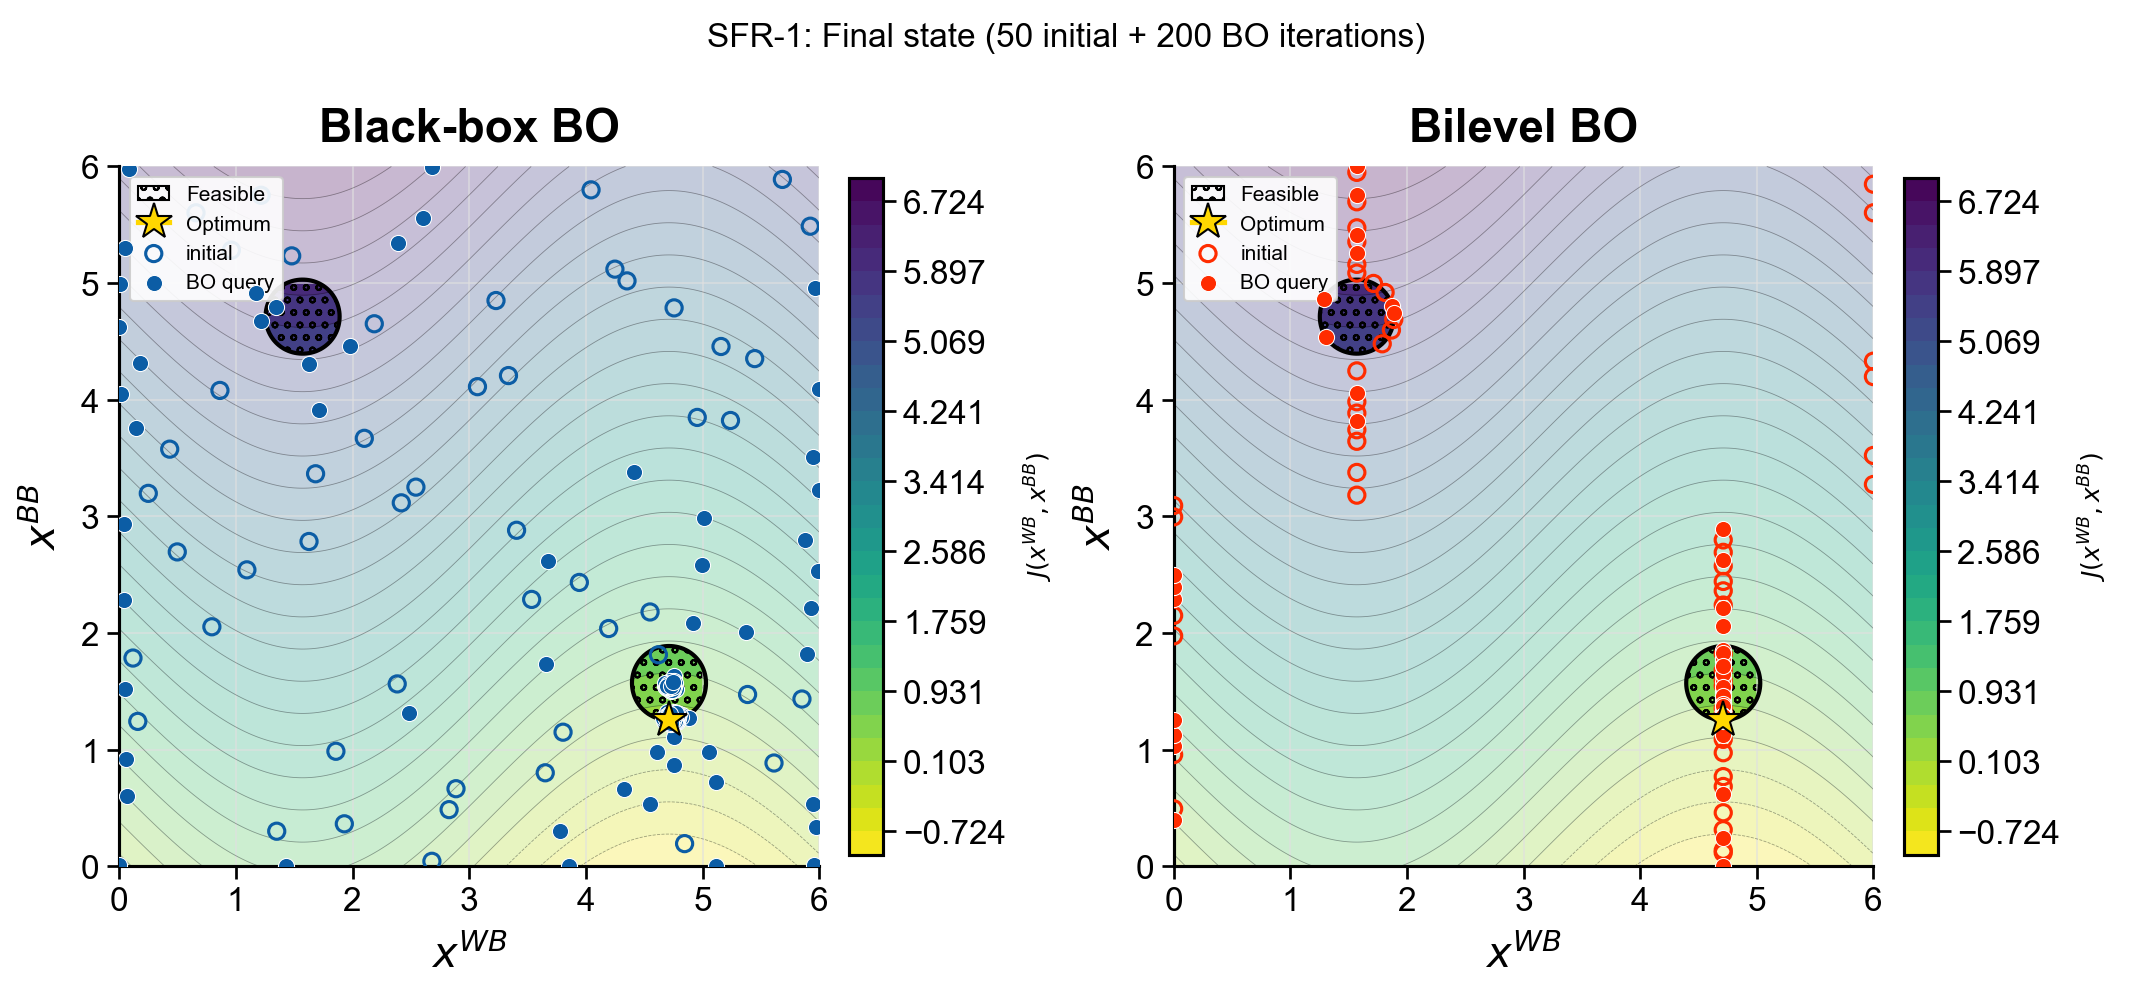

In [28]:
# ── SFR-1: Setup, background grids, and static preview ───────────────────────
from functions import create_small_feasible_region
from solvers import solve_blackbox_bo, solve_bilevel_bo

prob_sfr1 = create_small_feasible_region()
N_INIT_SFR, N_ITER_SFR, SEED_SFR = 50, 200, 0

res_bb_sfr1 = solve_blackbox_bo(
    prob_sfr1, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
    seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)
res_bi_sfr1 = solve_bilevel_bo(
    prob_sfr1, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
    seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)

bb1_xwb = res_bb_sfr1['X_history'][:, 0]
bb1_xbb = res_bb_sfr1['X_history'][:, 1]
bi1_xbb = np.asarray(res_bi_sfr1['X_bb_history']).ravel()
bi1_xwb = np.asarray([xw[0] for xw in res_bi_sfr1['X_wb_history']])
n_total1 = N_INIT_SFR + N_ITER_SFR
print(f'SFR-1 — BB-BO: {len(bb1_xwb)} pts,  Bi-BO: {len(bi1_xwb)} pts')

# Background grids
grid = 300
xw = np.linspace(0, 6, grid)
xb = np.linspace(0, 6, grid)
XW, XB = np.meshgrid(xw, xb)
J_grid = np.sin(XW) + XB
G_grid = np.sin(XW) * np.sin(XB) + 0.95
xwb_star = prob_sfr1.x_wb_optimal[0]
xbb_star = prob_sfr1.x_bb_optimal[0]

def draw_bg_sfr1(fig, ax, title):
    from matplotlib.patches import Rectangle
    levels_J = np.linspace(J_grid.min(), J_grid.max(), 30)
    cf = ax.contourf(XW, XB, J_grid, levels=levels_J, cmap='viridis_r')
    ax.contour(XW, XB, J_grid, levels=levels_J, colors='black', linewidths=0.4, alpha=0.35)
    cbar = fig.colorbar(cf, ax=ax, shrink=0.75, pad=0.03)
    cbar.set_label('$J(x^{WB}, x^{BB})$', fontsize=12)
    ax.contourf(XW, XB, G_grid, levels=[0, 1e3], colors=['white'], alpha=0.7)
    ax.contour(XW, XB, G_grid, levels=[0], colors=['black'], linewidths=2.0)
    ax.contourf(XW, XB, G_grid, levels=[-1e3, 0], colors=['none'], hatches=['oo'], alpha=0)
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor='none', edgecolor='black', hatch='oo', label='Feasible'))
    ax.plot(xwb_star, xbb_star, marker='*', color='gold', markersize=18,
            markeredgecolor='black', markeredgewidth=1.0, zorder=10, label='Optimum')
    ax.set_xlim(0, 6); ax.set_ylim(0, 6)
    ax.set_xlabel('$x^{WB}$'); ax.set_ylabel('$x^{BB}$')
    ax.set_title(title); ax.set_aspect('equal')

# Static preview
with plt.style.context(str(PRES_STYLE)):
    fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
    draw_bg_sfr1(fig, ax_bb, 'Black-box BO')
    draw_bg_sfr1(fig, ax_bi, 'Bilevel BO')
    ax_bb.scatter(bb1_xwb[:N_INIT_SFR], bb1_xbb[:N_INIT_SFR], s=60, facecolors='none',
                  edgecolors=C_BBBO, linewidths=1.5, zorder=5, label='initial')
    ax_bi.scatter(bi1_xwb[:N_INIT_SFR], bi1_xbb[:N_INIT_SFR], s=60, facecolors='none',
                  edgecolors=C_BIBO, linewidths=1.5, zorder=5, label='initial')
    ax_bb.scatter(bb1_xwb[N_INIT_SFR:], bb1_xbb[N_INIT_SFR:], s=60, c=C_BBBO,
                  edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
    ax_bi.scatter(bi1_xwb[N_INIT_SFR:], bi1_xbb[N_INIT_SFR:], s=60, c=C_BIBO,
                  edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
    ax_bb.legend(loc='upper left', fontsize=10)
    ax_bi.legend(loc='upper left', fontsize=10)
    fig.suptitle(f'SFR-1: Final state ({N_INIT_SFR} initial + {N_ITER_SFR} BO iterations)', fontsize=16)
    save_fig(fig, 'search_sfr1_static')
    plt.show()

Saved search_animation_sfr1.mp4


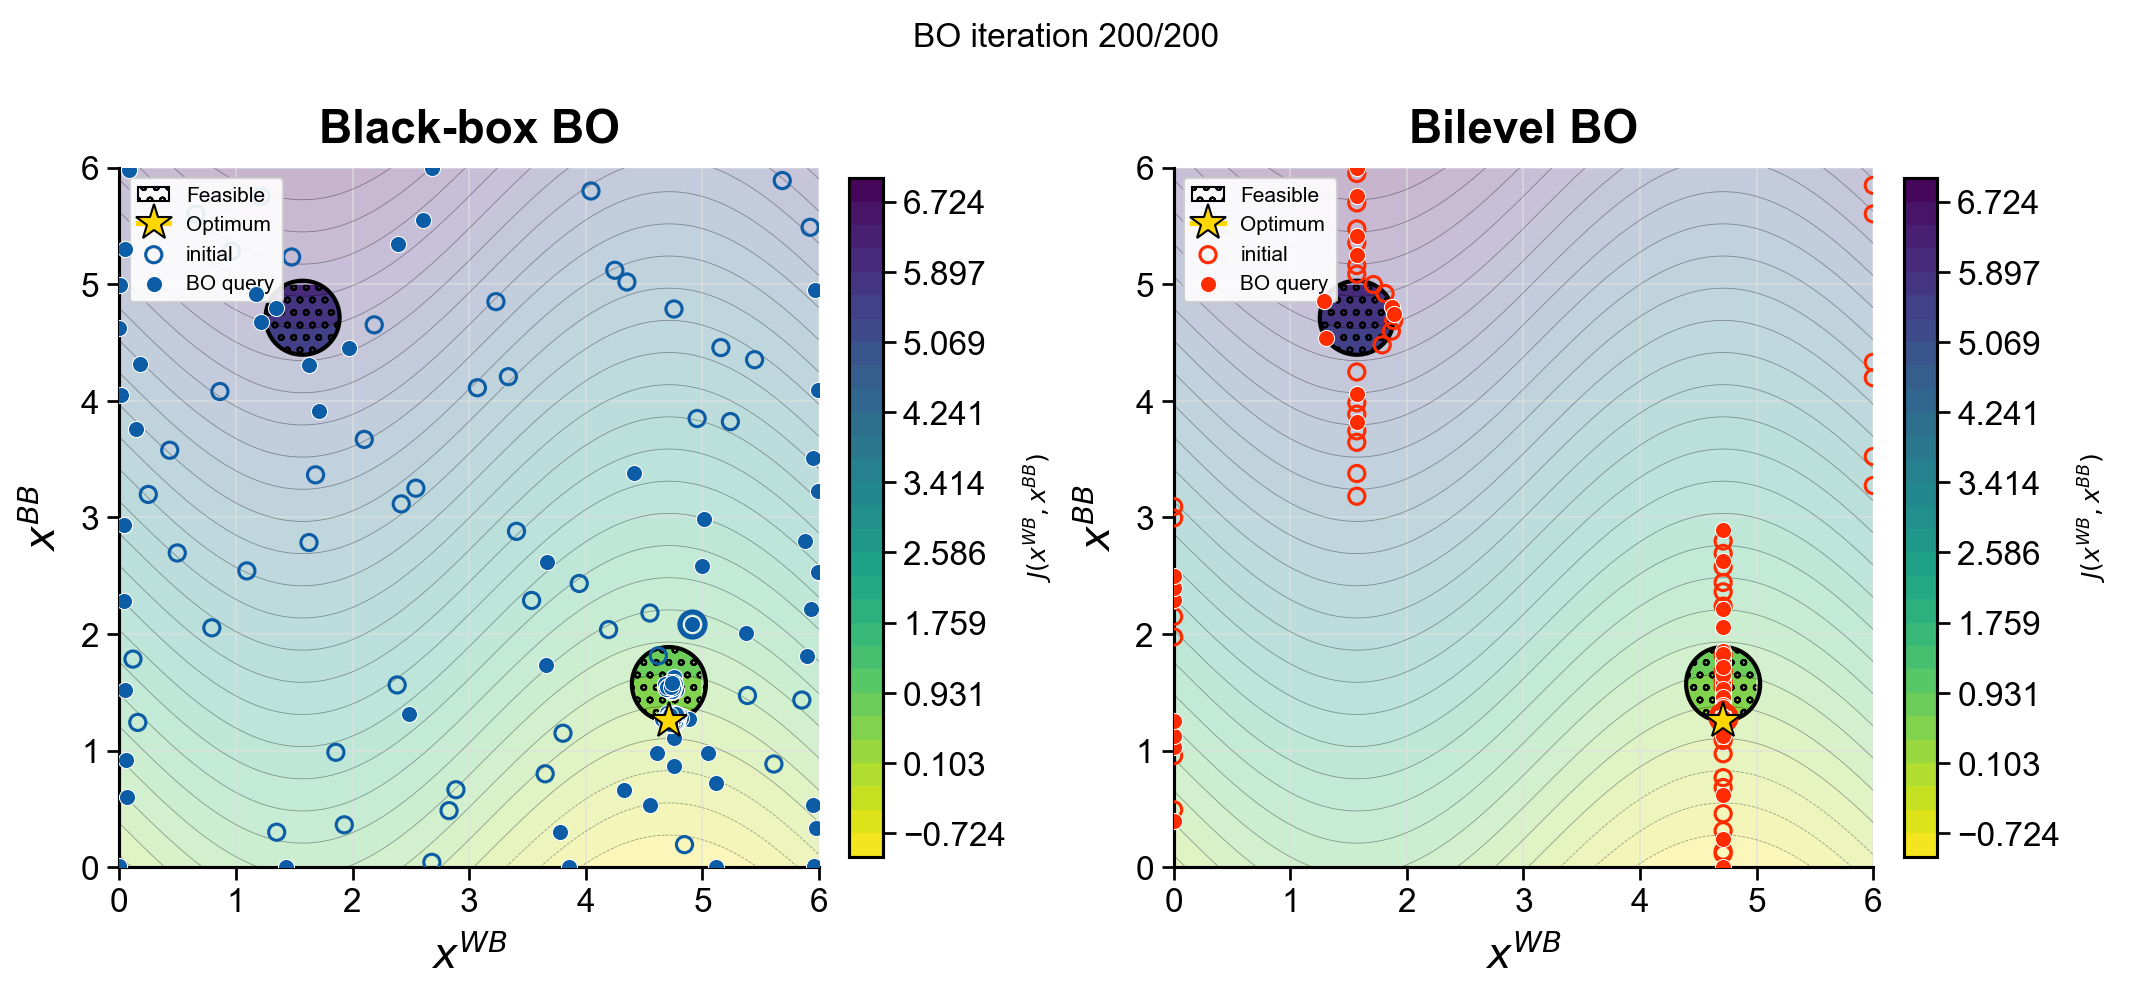

In [29]:
# ── SFR-1: Build animation ────────────────────────────────────────────────────
from matplotlib.animation import FuncAnimation, FFMpegWriter

with plt.style.context(str(PRES_STYLE)):
    fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
    draw_bg_sfr1(fig, ax_bb, 'Black-box BO')
    draw_bg_sfr1(fig, ax_bi, 'Bilevel BO')

    scat_bb_init = ax_bb.scatter([], [], s=60, facecolors='none', edgecolors=C_BBBO,
                                  linewidths=1.5, zorder=5, label='initial')
    scat_bb_bo   = ax_bb.scatter([], [], s=60, c=C_BBBO, edgecolors='white',
                                  linewidths=0.5, zorder=6, label='BO query')
    scat_bi_init = ax_bi.scatter([], [], s=60, facecolors='none', edgecolors=C_BIBO,
                                  linewidths=1.5, zorder=5, label='initial')
    scat_bi_bo   = ax_bi.scatter([], [], s=60, c=C_BIBO, edgecolors='white',
                                  linewidths=0.5, zorder=6, label='BO query')
    high_bb, = ax_bb.plot([], [], 'o', ms=12, mec=C_BBBO, mfc='none', mew=2.5, zorder=7)
    high_bi, = ax_bi.plot([], [], 'o', ms=12, mec=C_BIBO, mfc='none', mew=2.5, zorder=7)
    iter_text = fig.suptitle('', fontsize=16)
    ax_bb.legend(loc='upper left', fontsize=10)
    ax_bi.legend(loc='upper left', fontsize=10)

    def init1():
        return scat_bb_init, scat_bb_bo, scat_bi_init, scat_bi_bo, high_bb, high_bi, iter_text

    def update1(frame):
        k = frame + 1
        if k <= N_INIT_SFR:
            scat_bb_init.set_offsets(np.c_[bb1_xwb[:k], bb1_xbb[:k]])
            scat_bb_bo.set_offsets(np.empty((0, 2)))
            scat_bi_init.set_offsets(np.c_[bi1_xwb[:k], bi1_xbb[:k]])
            scat_bi_bo.set_offsets(np.empty((0, 2)))
            iter_text.set_text(f'Initial sample {k}/{N_INIT_SFR}')
        else:
            scat_bb_init.set_offsets(np.c_[bb1_xwb[:N_INIT_SFR], bb1_xbb[:N_INIT_SFR]])
            scat_bb_bo.set_offsets(np.c_[bb1_xwb[N_INIT_SFR:k], bb1_xbb[N_INIT_SFR:k]])
            scat_bi_init.set_offsets(np.c_[bi1_xwb[:N_INIT_SFR], bi1_xbb[:N_INIT_SFR]])
            scat_bi_bo.set_offsets(np.c_[bi1_xwb[N_INIT_SFR:k], bi1_xbb[N_INIT_SFR:k]])
            iter_text.set_text(f'BO iteration {k - N_INIT_SFR}/{N_ITER_SFR}')
        high_bb.set_data([bb1_xwb[k-1]], [bb1_xbb[k-1]])
        high_bi.set_data([bi1_xwb[k-1]], [bi1_xbb[k-1]])
        return scat_bb_init, scat_bb_bo, scat_bi_init, scat_bi_bo, high_bb, high_bi, iter_text

    anim = FuncAnimation(fig, update1, init_func=init1, frames=n_total1, interval=200, blit=False)
    anim.save(REPORT_FIGS_DIR / 'search_animation_sfr1.mp4', writer=FFMpegWriter(fps=5))
    print('Saved search_animation_sfr1.mp4')
    plt.show()

SFR-2 — BB-BO: 250 pts,  Bi-BO: 250 pts


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved search_sfr2_static.eps/.pdf


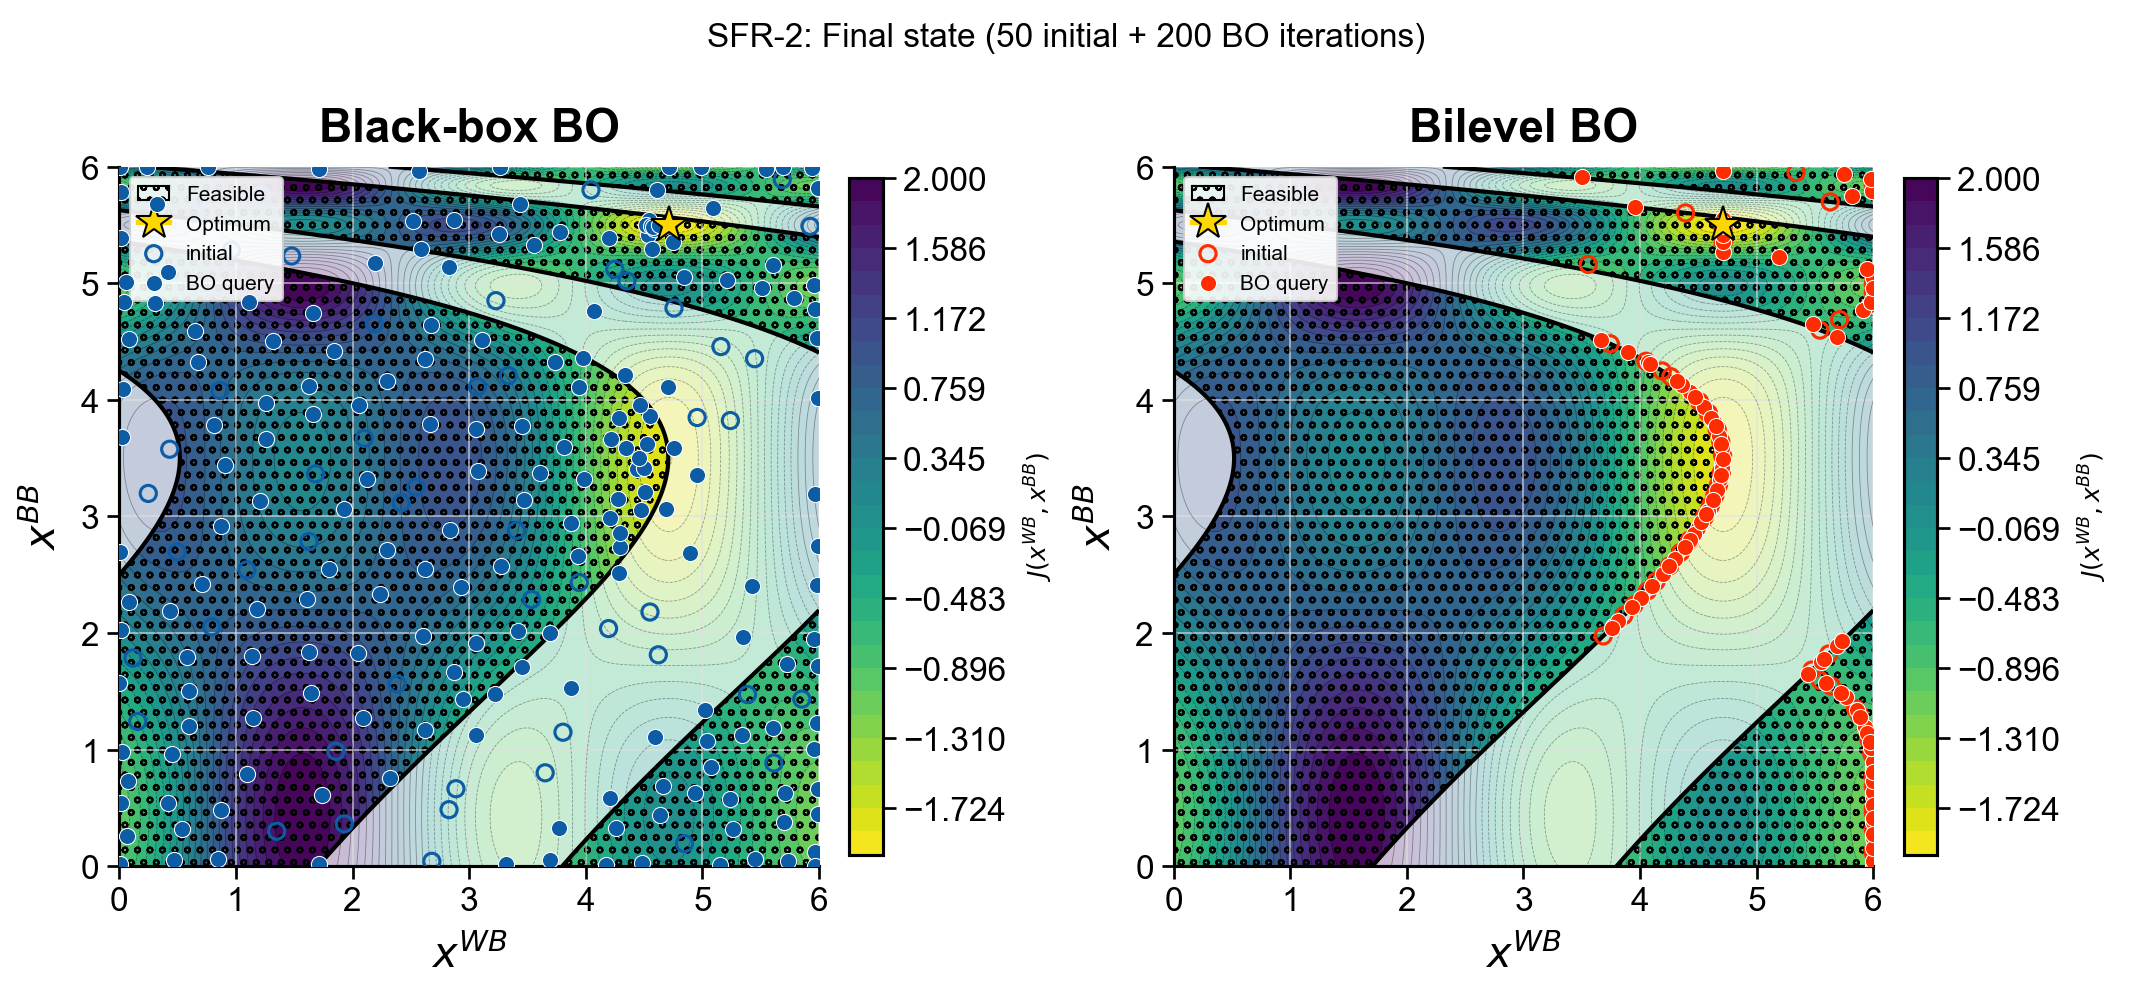

In [30]:
# ── SFR-2: Setup, background grids, and static preview ───────────────────────
from functions import create_small_feasible_region2
from solvers import solve_blackbox_bo as _solve_bb2, solve_bilevel_bo as _solve_bi2

prob_sfr2 = create_small_feasible_region2()

res_bb2 = _solve_bb2(prob_sfr2, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
                      seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)
res_bi2 = _solve_bi2(prob_sfr2, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
                      seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)

bb2_xwb = res_bb2['X_history'][:, 0]
bb2_xbb = res_bb2['X_history'][:, 1]
bi2_xbb = np.asarray(res_bi2['X_bb_history']).ravel()
bi2_xwb = np.asarray([xw[0] for xw in res_bi2['X_wb_history']])
n_total2 = N_INIT_SFR + N_ITER_SFR
print(f'SFR-2 — BB-BO: {len(bb2_xwb)} pts,  Bi-BO: {len(bi2_xwb)} pts')

# Background grids
grid2 = 300
xw2 = np.linspace(0, 6, grid2)
xb2 = np.linspace(0, 6, grid2)
XW2, XB2 = np.meshgrid(xw2, xb2)
Y2_grid = (XB2 - 5.5) / 2 * np.exp(XB2 / 2)
J2_grid = np.cos(2 * XW2) * np.cos(Y2_grid) + np.sin(XW2)
G2_grid = np.cos(XW2) * np.cos(Y2_grid) - np.sin(XW2) * np.sin(Y2_grid) - 0.5
xwb2_star = prob_sfr2.x_wb_optimal[0]
xbb2_star = prob_sfr2.x_bb_optimal[0]

def draw_bg_sfr2(fig, ax, title):
    from matplotlib.patches import Rectangle
    levels_J = np.linspace(J2_grid.min(), J2_grid.max(), 30)
    cf = ax.contourf(XW2, XB2, J2_grid, levels=levels_J, cmap='viridis_r')
    ax.contour(XW2, XB2, J2_grid, levels=levels_J, colors='black', linewidths=0.4, alpha=0.35)
    cbar = fig.colorbar(cf, ax=ax, shrink=0.75, pad=0.03)
    cbar.set_label('$J(x^{WB}, x^{BB})$', fontsize=12)
    ax.contourf(XW2, XB2, G2_grid, levels=[0, 1e3], colors=['white'], alpha=0.7)
    ax.contour(XW2, XB2, G2_grid, levels=[0], colors=['black'], linewidths=2.0)
    ax.contourf(XW2, XB2, G2_grid, levels=[-1e3, 0], colors=['none'], hatches=['oo'], alpha=0)
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor='none', edgecolor='black', hatch='oo', label='Feasible'))
    ax.plot(xwb2_star, xbb2_star, marker='*', color='gold', markersize=18,
            markeredgecolor='black', markeredgewidth=1.0, zorder=10, label='Optimum')
    ax.set_xlim(0, 6); ax.set_ylim(0, 6)
    ax.set_xlabel('$x^{WB}$'); ax.set_ylabel('$x^{BB}$')
    ax.set_title(title); ax.set_aspect('equal')

# Static preview
with plt.style.context(str(PRES_STYLE)):
    fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
    draw_bg_sfr2(fig, ax_bb, 'Black-box BO')
    draw_bg_sfr2(fig, ax_bi, 'Bilevel BO')
    ax_bb.scatter(bb2_xwb[:N_INIT_SFR], bb2_xbb[:N_INIT_SFR], s=60, facecolors='none',
                  edgecolors=C_BBBO, linewidths=1.5, zorder=5, label='initial')
    ax_bi.scatter(bi2_xwb[:N_INIT_SFR], bi2_xbb[:N_INIT_SFR], s=60, facecolors='none',
                  edgecolors=C_BIBO, linewidths=1.5, zorder=5, label='initial')
    ax_bb.scatter(bb2_xwb[N_INIT_SFR:], bb2_xbb[N_INIT_SFR:], s=60, c=C_BBBO,
                  edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
    ax_bi.scatter(bi2_xwb[N_INIT_SFR:], bi2_xbb[N_INIT_SFR:], s=60, c=C_BIBO,
                  edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
    ax_bb.legend(loc='upper left', fontsize=10)
    ax_bi.legend(loc='upper left', fontsize=10)
    fig.suptitle(f'SFR-2: Final state ({N_INIT_SFR} initial + {N_ITER_SFR} BO iterations)', fontsize=16)
    save_fig(fig, 'search_sfr2_static')
    plt.show()

Saved search_animation_sfr2.mp4


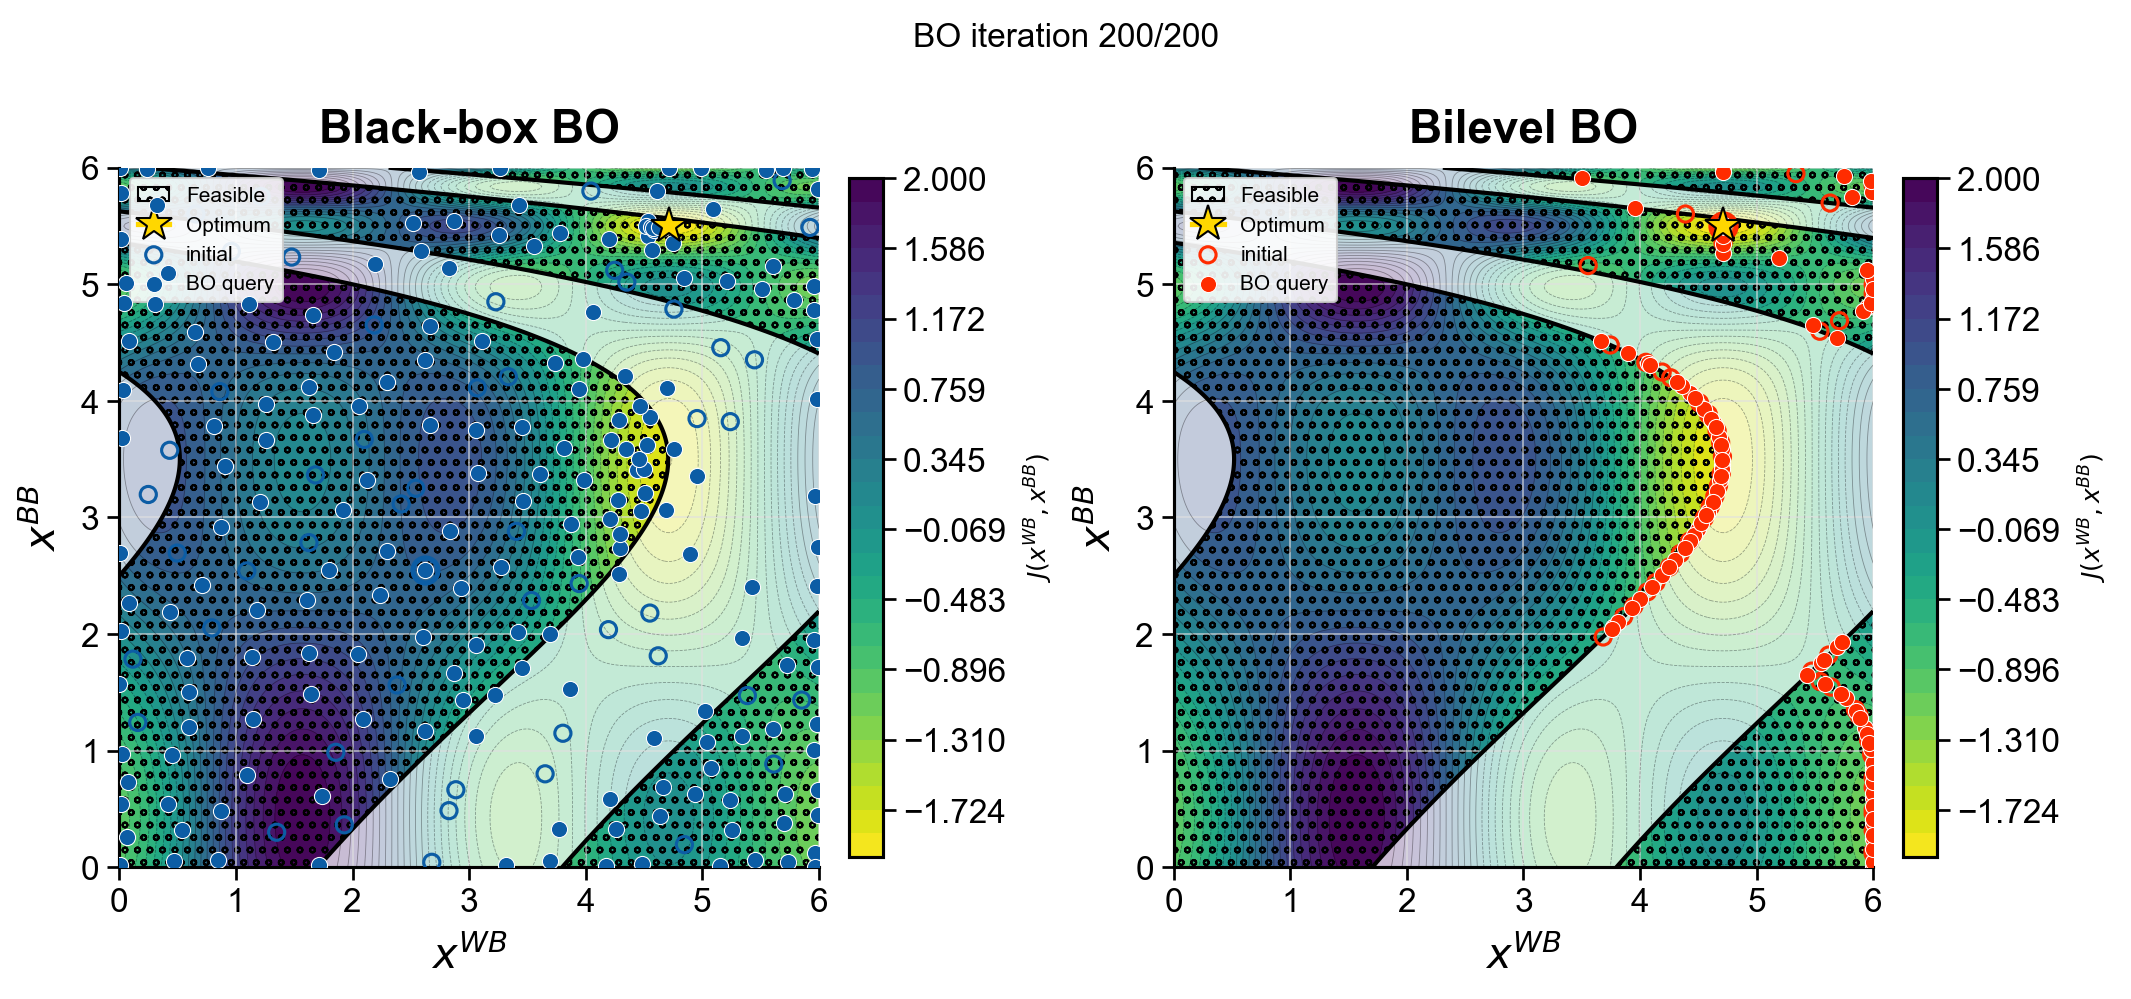

In [31]:
# ── SFR-2: Build animation ────────────────────────────────────────────────────
from matplotlib.animation import FuncAnimation, FFMpegWriter

with plt.style.context(str(PRES_STYLE)):
    fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
    draw_bg_sfr2(fig, ax_bb, 'Black-box BO')
    draw_bg_sfr2(fig, ax_bi, 'Bilevel BO')

    scat_bb2_init = ax_bb.scatter([], [], s=60, facecolors='none', edgecolors=C_BBBO,
                                   linewidths=1.5, zorder=5, label='initial')
    scat_bb2_bo   = ax_bb.scatter([], [], s=60, c=C_BBBO, edgecolors='white',
                                   linewidths=0.5, zorder=6, label='BO query')
    scat_bi2_init = ax_bi.scatter([], [], s=60, facecolors='none', edgecolors=C_BIBO,
                                   linewidths=1.5, zorder=5, label='initial')
    scat_bi2_bo   = ax_bi.scatter([], [], s=60, c=C_BIBO, edgecolors='white',
                                   linewidths=0.5, zorder=6, label='BO query')
    high_bb2, = ax_bb.plot([], [], 'o', ms=12, mec=C_BBBO, mfc='none', mew=2.5, zorder=7)
    high_bi2, = ax_bi.plot([], [], 'o', ms=12, mec=C_BIBO, mfc='none', mew=2.5, zorder=7)
    iter_text2 = fig.suptitle('', fontsize=16)
    ax_bb.legend(loc='upper left', fontsize=10)
    ax_bi.legend(loc='upper left', fontsize=10)

    def init2():
        return scat_bb2_init, scat_bb2_bo, scat_bi2_init, scat_bi2_bo, high_bb2, high_bi2, iter_text2

    def update2(frame):
        k = frame + 1
        if k <= N_INIT_SFR:
            scat_bb2_init.set_offsets(np.c_[bb2_xwb[:k], bb2_xbb[:k]])
            scat_bb2_bo.set_offsets(np.empty((0, 2)))
            scat_bi2_init.set_offsets(np.c_[bi2_xwb[:k], bi2_xbb[:k]])
            scat_bi2_bo.set_offsets(np.empty((0, 2)))
            iter_text2.set_text(f'Initial sample {k}/{N_INIT_SFR}')
        else:
            scat_bb2_init.set_offsets(np.c_[bb2_xwb[:N_INIT_SFR], bb2_xbb[:N_INIT_SFR]])
            scat_bb2_bo.set_offsets(np.c_[bb2_xwb[N_INIT_SFR:k], bb2_xbb[N_INIT_SFR:k]])
            scat_bi2_init.set_offsets(np.c_[bi2_xwb[:N_INIT_SFR], bi2_xbb[:N_INIT_SFR]])
            scat_bi2_bo.set_offsets(np.c_[bi2_xwb[N_INIT_SFR:k], bi2_xbb[N_INIT_SFR:k]])
            iter_text2.set_text(f'BO iteration {k - N_INIT_SFR}/{N_ITER_SFR}')
        high_bb2.set_data([bb2_xwb[k-1]], [bb2_xbb[k-1]])
        high_bi2.set_data([bi2_xwb[k-1]], [bi2_xbb[k-1]])
        return scat_bb2_init, scat_bb2_bo, scat_bi2_init, scat_bi2_bo, high_bb2, high_bi2, iter_text2

    anim2 = FuncAnimation(fig, update2, init_func=init2, frames=n_total2, interval=200, blit=False)
    anim2.save(REPORT_FIGS_DIR / 'search_animation_sfr2.mp4', writer=FFMpegWriter(fps=5))
    print('Saved search_animation_sfr2.mp4')
    plt.show()

---
## 7. Paper Claims Validation

Automated checks against each claim from the paper.

In [32]:
# ── Automated claim validation ────────────────────────────────────────────────

def check(label, condition, detail):
    status = '[CONFIRMED]' if condition else '[CHECK NEEDED]'
    print(f'{status} {label}')
    print(f'  {detail}\n')

print('=' * 70)
print('PAPER CLAIMS VALIDATION')
print('=' * 70 + '\n')

# 1. "14x-277,000x lower regret on all 13 problems"
min_ratio = df_stats['regret_ratio'].min()
max_ratio = df_stats['regret_ratio'].max()
all_above_1 = (df_stats['regret_ratio'] > 1).all()
check(
    'Claim 1: Bi-BO achieves lower regret on all 13 problems',
    all_above_1,
    f'Ratio range: {min_ratio:.1f}x -- {max_ratio:.0f}x (paper claims 14x--277,000x)'
)

# 2. "Advantage grows with dimension"
rho, p_spearman = spearmanr(df_stats['total_dim'], df_stats['regret_ratio'])
dim2 = df_stats[df_stats['total_dim'] == 2]['regret_ratio']
dim3 = df_stats[df_stats['total_dim'] == 3]['regret_ratio']
dim4 = df_stats[df_stats['total_dim'] == 4]['regret_ratio']
dim5 = df_stats[df_stats['total_dim'] == 5]['regret_ratio']
check(
    'Claim 2: Advantage grows with dimension',
    rho > 0 and p_spearman < 0.1,
    f'Spearman rho={rho:.3f}, p={p_spearman:.4f}\n'
    f'  2D median: {dim2.median():.0f}x, 3D median: {dim3.median():.0f}x, '
    f'4D median: {dim4.median() if len(dim4) > 0 else "N/A"}x, '
    f'5D median: {dim5.median() if len(dim5) > 0 else "N/A"}x'
)

# 3. "Tight-constraint problems show >100,000x improvement"
tight_problems = ['Heat-Exchanger', 'Distillation', 'Small-Feasible-Region', 'Small-Feasible-Region-2']
tight_ratios = df_stats[df_stats['problem'].isin(tight_problems)][['problem', 'regret_ratio']]
max_tight = tight_ratios['regret_ratio'].max()
check(
    'Claim 3: Tight-constraint problems show very large improvement',
    max_tight > 100000,
    f'Tight-constraint ratios:\n' +
    '\n'.join(f'    {r["problem"]}: {r["regret_ratio"]:.0f}x' for _, r in tight_ratios.iterrows())
)

# 4. "Comparable wall time for 12/13 problems"
n_comparable = df_time['comparable'].sum()
outliers = df_time[~df_time['comparable']]
check(
    'Claim 4: Comparable wall time for most problems',
    n_comparable >= 12,
    f'{n_comparable}/{len(df_time)} problems within 2x wall time ratio' +
    (f'\n  Outlier(s): ' + ', '.join(f'{r["problem"]} ({r["time_ratio"]:.1f}x)' for _, r in outliers.iterrows()) if len(outliers) > 0 else '')
)

# 5. "Robust to hyperparameters: n_init in {1,50}, xi in {0.001,1.0}"
worst_case_ratios = {}
for pname in problem_names:
    worst = np.inf
    for (ni, xi), d in all_data_merged.items():
        results = d['results']
        bb_f = [np.abs(r[-1]) for r in results[pname]['blackbox_bo_ei']['regrets']
                if np.isfinite(r[-1])]
        bi_f = [np.abs(r[-1]) for r in results[pname]['bilevel_bo_ei']['regrets']
                if np.isfinite(r[-1])]
        if bb_f and bi_f:
            ratio = np.mean(bb_f) / max(np.mean(bi_f), 1e-15)
            worst = min(worst, ratio)
    worst_case_ratios[pname] = worst

all_robust = all(r > 1 for r in worst_case_ratios.values())
min_worst = min(worst_case_ratios.values())
min_worst_prob = min(worst_case_ratios, key=worst_case_ratios.get)
check(
    'Claim 5: Robust to hyperparameters',
    all_robust,
    f'Bi-BO dominates across all {len(all_data_merged)} (n_init, xi) configs: {all_robust}\n'
    f'  Worst-case ratio: {min_worst:.1f}x ({min_worst_prob})'
)

# 6. "Matches 20-restart NLP quality with ~200 evaluations"
res = xibest_data[ninit_values[0]]['results']
nlp_evals_avg = np.mean([np.mean(res[p]['multistart_slsqp']['n_fbb_evals']) for p in problem_names])
bi_evals_avg = np.mean([np.mean(res[p]['bilevel_bo_ei']['n_fbb_evals']) for p in problem_names])
n_bi_matches = 0
for pname in problem_names:
    prob = res[pname]
    nlp_reg = np.mean(np.abs(prob['multistart_slsqp']['final_regrets']))
    bi_f = [np.abs(r[-1]) for r in prob['bilevel_bo_ei']['regrets'] if np.isfinite(r[-1])]
    bi_reg = np.mean(bi_f) if bi_f else np.inf
    if bi_reg <= nlp_reg * 10:
        n_bi_matches += 1
check(
    'Claim 6: Bi-BO matches NLP quality with fewer evaluations',
    bi_evals_avg < nlp_evals_avg and n_bi_matches >= 10,
    f'Bi-BO evals: {bi_evals_avg:.0f}, NLP evals: {nlp_evals_avg:.0f}\n'
    f'  Bi-BO within 10x of NLP regret on {n_bi_matches}/{len(problem_names)} problems'
)

PAPER CLAIMS VALIDATION

[CHECK NEEDED] Claim 1: Bi-BO achieves lower regret on all 13 problems
  Ratio range: 0.9x -- 143629503x (paper claims 14x--277,000x)

[CHECK NEEDED] Claim 2: Advantage grows with dimension
  Spearman rho=0.224, p=0.4619
  2D median: 771x, 3D median: 95506276x, 4D median: 259.69137120982697x, 5D median: 66990.72084559083x

[CONFIRMED] Claim 3: Tight-constraint problems show very large improvement
  Tight-constraint ratios:
    Distillation: 1032361x
    Heat-Exchanger: 143629503x
    Small-Feasible-Region: 1x
    Small-Feasible-Region-2: 2702x

[CHECK NEEDED] Claim 4: Comparable wall time for most problems
  11/13 problems within 2x wall time ratio
  Outlier(s): Small-Feasible-Region (4.0x), Williams-Otto (10.3x)

[CHECK NEEDED] Claim 5: Robust to hyperparameters
  Bi-BO dominates across all 21 (n_init, xi) configs: False
  Worst-case ratio: 0.1x (Small-Feasible-Region)

[CHECK NEEDED] Claim 6: Bi-BO matches NLP quality with fewer evaluations
  Bi-BO evals: 205

---
## 8. Export

In [33]:
# ── Save DataFrames and list outputs ──────────────────────────────────────────
out_dir = Path.cwd()

df_stats.to_csv(out_dir / 'stats_per_problem.csv', index=False)
df_time.to_csv(out_dir / 'wall_time_comparison.csv', index=False)
df_pivot.to_csv(out_dir / 'sensitivity_pivot.csv')

print(f'Exported CSVs to {out_dir}:')
print(f'  stats_per_problem.csv    ({len(df_stats)} rows)')
print(f'  wall_time_comparison.csv ({len(df_time)} rows)')
print(f'  sensitivity_pivot.csv    ({len(df_pivot)} rows)')

print(f'\nFigures saved to {REPORT_FIGS_DIR}:')
for f in sorted(REPORT_FIGS_DIR.glob('*.pdf')):
    print(f'  {f.name}')

Exported CSVs to /Users/jeh/Library/CloudStorage/OneDrive-TheUniversityofTexasatAustin/business/UTexas/projects/Greybox Multi-scale Optimization/Notebooks:
  stats_per_problem.csv    (13 rows)
  wall_time_comparison.csv (13 rows)
  sensitivity_pivot.csv    (7 rows)

Figures saved to /Users/jeh/Library/CloudStorage/OneDrive-TheUniversityofTexasatAustin/business/UTexas/projects/Greybox Multi-scale Optimization/Report/figs:
  convergence_grid.pdf
  convergence_speed.pdf
  cstr_convergence.pdf
  dim_vs_constraint_scatter-eps-converted-to.pdf
  dimensionality_scaling.pdf
  effect_size_forest.pdf
  fbb_evaluations.pdf
  feasibility_rates-eps-converted-to.pdf
  feasibility_rates.pdf
  ninit_robustness.pdf
  regret_boxplots.pdf
  sample_crossover-eps-converted-to.pdf
  scatter_bb_vs_bi.pdf
  search_sfr1_static.pdf
  search_sfr2_static.pdf
  sfr1_search-eps-converted-to.pdf
  sfr1_search.pdf
  sfr2_search-eps-converted-to.pdf
  sfr2_search.pdf
  sfr_convergence-eps-converted-to.pdf
  sfr_conver